# Unicament mappers y ver los indices

## Librerás

In [33]:
import pandas as pd
import numpy as np
import random

import plotly
import requests
from bs4 import BeautifulSoup
import ruptures as rpt
import yfinance as yf

import plotly.graph_objects as go
import matplotlib.pyplot as plt

import kmapper as km
import subprocess
import sys
import networkx as nx
subprocess.check_call([sys.executable, "-m", "pip", "install", "plotly", "nbformat>=4.2.0"])
import sklearn.cluster

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.cluster import DBSCAN, KMeans
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots


## Datos

### Sacar tickers

In [34]:

# URL de la lista del S&P 500
url = "https://www.slickcharts.com/sp500"


# Hacer la petición con headers para evitar bloqueos
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
}
response = requests.get(url, headers=headers)
response.raise_for_status()  # Raise exception for bad status codes

# Parsear el HTML
soup = BeautifulSoup(response.text, 'html.parser')

# Encontrar la tabla
table = soup.find('table')

if table:
    # Leer la tabla con pandas
    df = pd.read_html(str(table))[0]
    
    # Extraer los tickers
    if 'Symbol' in df.columns:
        tickers = df['Symbol'].tolist()
        print(f"Found {len(tickers)} tickers")
        print("First 10 tickers:", tickers[:10])
    else:
        print("Available columns:", df.columns.tolist())

    # Extraer los pesos
    if 'Weight' in df.columns:
        weights = df['Weight'].tolist()
        print(f"Found {len(weights)} weights")
        print("First 10 weights:", weights[:10])
    else:
        print("Available columns:", df.columns.tolist())
else:
    print("No table found on the page")

# En la lista de ticker, reemplazar los "." por "-"
tickers = [ticker.replace('.', '-') for ticker in tickers]
print("Tickers after replacement:", tickers[:10])

Found 504 tickers
First 10 tickers: ['NVDA', 'AAPL', 'MSFT', 'AMZN', 'GOOGL', 'AVGO', 'GOOG', 'META', 'TSLA', 'BRK.B']
Found 504 weights
First 10 weights: ['7.96%', '6.50%', '6.15%', '4.36%', '2.87%', '2.77%', '2.68%', '2.62%', '2.45%', '1.72%']
Tickers after replacement: ['NVDA', 'AAPL', 'MSFT', 'AMZN', 'GOOGL', 'AVGO', 'GOOG', 'META', 'TSLA', 'BRK-B']


### Info financiera

In [35]:
# =======================================================
# 📊 RECOPILACIÓN DE INFORMACIÓN FUNDAMENTAL DE TICKERS
# =======================================================

import os

# Verificar si el archivo ya existe
csv_filename = 'sp500_ticker_info_database.csv'

if os.path.exists(csv_filename):
    # ✅ ARCHIVO EXISTE - Cargar datos existentes
    print("✅ Archivo 'sp500_ticker_info_database.csv' encontrado")
    print("📂 Cargando información desde archivo guardado...")
    print("=" * 80)
    
    try:
        ticker_info_df = pd.read_csv(csv_filename, index_col=0)
        
        # Convertir DataFrame a diccionario para ticker_info_db
        ticker_info_db = ticker_info_df.to_dict('index')
        
        print(f"✅ Datos cargados exitosamente")
        print(f"   📊 Total de tickers: {len(ticker_info_df)}")
        print(f"   📋 Columnas: {len(ticker_info_df.columns)}")
        print(f"\n💡 Para actualizar los datos, elimina el archivo '{csv_filename}' y vuelve a ejecutar esta celda")
        
    except Exception as e:
        print(f"❌ Error al cargar el archivo: {e}")
        print(f"⚠️  Se procederá a descargar los datos nuevamente...")
        # Si hay error, forzar descarga
        os.remove(csv_filename) if os.path.exists(csv_filename) else None
        ticker_info_df = None

else:
    # ❌ ARCHIVO NO EXISTE - Descargar información
    print("⚠️  Archivo 'sp500_ticker_info_database.csv' no encontrado")
    print("🔍 Descargando información detallada de todos los tickers del S&P 500...")
    print("⏱️  Esto puede tardar varios minutos...")
    print("=" * 80)
    
    ticker_info_db = {}
    failed_tickers = []
    
    for idx, ticker in enumerate(tickers, 1):
        try:
            # Mostrar progreso cada 50 tickers
            if idx % 50 == 0 or idx == 1:
                print(f"   Procesando ticker {idx}/{len(tickers)}: {ticker}")
            
            stock = yf.Ticker(ticker)
            info = stock.info
            
            # Extraer información relevante
            ticker_info_db[ticker] = {
                # Información básica
                'sector': info.get('sector', 'Unknown'),
                'industry': info.get('industry', 'Unknown'),
                'market_cap': info.get('marketCap', None),
                'country': info.get('country', 'Unknown'),
                'full_name': info.get('longName', ticker),
                
                # Métricas de valoración
                'pe_ratio': info.get('trailingPE', None),
                'forward_pe': info.get('forwardPE', None),
                'peg_ratio': info.get('pegRatio', None),
                'price_to_book': info.get('priceToBook', None),
                'price_to_sales': info.get('priceToSalesTrailing12Months', None),
                'enterprise_value': info.get('enterpriseValue', None),
                'ev_to_ebitda': info.get('enterpriseToEbitda', None),
                
                # Dividendos
                'dividend_yield': info.get('dividendYield', None),
                'dividend_rate': info.get('dividendRate', None),
                'payout_ratio': info.get('payoutRatio', None),
                'five_year_avg_dividend_yield': info.get('fiveYearAvgDividendYield', None),
                
                # Rentabilidad
                'profit_margins': info.get('profitMargins', None),
                'operating_margins': info.get('operatingMargins', None),
                'gross_margins': info.get('grossMargins', None),
                'roe': info.get('returnOnEquity', None),
                'roa': info.get('returnOnAssets', None),
                
                # Crecimiento
                'revenue_growth': info.get('revenueGrowth', None),
                'earnings_growth': info.get('earningsGrowth', None),
                'earnings_quarterly_growth': info.get('earningsQuarterlyGrowth', None),
                
                # Riesgo y volatilidad
                'beta': info.get('beta', None),
                '52week_high': info.get('fiftyTwoWeekHigh', None),
                '52week_low': info.get('fiftyTwoWeekLow', None),
                '52week_change': info.get('52WeekChange', None),
                
                # Liquidez y deuda
                'current_ratio': info.get('currentRatio', None),
                'quick_ratio': info.get('quickRatio', None),
                'debt_to_equity': info.get('debtToEquity', None),
                'total_debt': info.get('totalDebt', None),
                'total_cash': info.get('totalCash', None),
                
                # Analistas y recomendaciones
                'recommendation': info.get('recommendationKey', 'Unknown'),
                'recommendation_mean': info.get('recommendationMean', None),
                'target_mean_price': info.get('targetMeanPrice', None),
                'target_high_price': info.get('targetHighPrice', None),
                'target_low_price': info.get('targetLowPrice', None),
                'number_of_analysts': info.get('numberOfAnalystOpinions', None),
                
                # Información adicional
                'employees': info.get('fullTimeEmployees', None),
                'exchange': info.get('exchange', 'Unknown'),
                'quote_type': info.get('quoteType', 'Unknown'),
            }
            
        except Exception as e:
            failed_tickers.append(ticker)
            ticker_info_db[ticker] = {
                'sector': 'Unknown',
                'industry': 'Unknown',
                'error': str(e)
            }
    
    print(f"\n{'='*80}")
    print(f"📊 RESUMEN DE DESCARGA:")
    print(f"   ✅ Tickers procesados: {len(ticker_info_db)}")
    if failed_tickers:
        print(f"   ❌ Tickers fallidos ({len(failed_tickers)}): {', '.join(failed_tickers[:10])}{'...' if len(failed_tickers) > 10 else ''}")
    
    # Crear DataFrame para análisis fácil
    ticker_info_df = pd.DataFrame.from_dict(ticker_info_db, orient='index')
    
    print(f"\n   📋 DataFrame de información creado: {ticker_info_df.shape}")
    
    # Guardar en CSV para uso posterior
    ticker_info_df.to_csv(csv_filename)
    print(f"   💾 Base de datos guardada en '{csv_filename}'")

# Mostrar primeras filas (común para ambos casos)
print(f"\n{'='*80}")
print("📋 Primeras filas de la base de datos:")
display(ticker_info_df.head(10))

✅ Archivo 'sp500_ticker_info_database.csv' encontrado
📂 Cargando información desde archivo guardado...
✅ Datos cargados exitosamente
   📊 Total de tickers: 503
   📋 Columnas: 43

💡 Para actualizar los datos, elimina el archivo 'sp500_ticker_info_database.csv' y vuelve a ejecutar esta celda

📋 Primeras filas de la base de datos:


,sector,industry,market_cap,country,full_name,pe_ratio,forward_pe,peg_ratio,price_to_book,price_to_sales,...,recommendation,recommendation_mean,target_mean_price,target_high_price,target_low_price,number_of_analysts,employees,exchange,quote_type,error
NVDA,Technology,Semiconductors,5.105445e+12,United States,NVIDIA Corporation,59.912860,50.896847,NaN,50.983470,30.900524,...,strong_buy,1.34375,229.32070,350.00,100.0,57.0,36000.0,NMS,EQUITY,NaN
AAPL,Technology,Consumer Electronics,3.961836e+12,United States,Apple Inc.,35.941017,32.264740,NaN,53.720695,9.519959,...,buy,2.00000,278.01633,345.00,200.0,41.0,166000.0,NMS,EQUITY,NaN
MSFT,Technology,Software - Infrastructure,3.842837e+12,United States,Microsoft Corporation,36.721590,34.584614,NaN,10.586404,13.079236,...,strong_buy,1.21053,626.26500,730.00,483.0,52.0,228000.0,NMS,EQUITY,NaN
AMZN,Consumer Cyclical,Internet Retail,2.734878e+12,United States,"Amazon.com, Inc.",36.134182,41.598373,NaN,7.396709,3.955811,...,strong_buy,1.29851,288.83392,351.87,240.0,61.0,1578000.0,NMS,EQUITY,NaN
GOOGL,Communication Services,Internet Content & Information,3.412471e+12,United States,Alphabet Inc.,27.916010,31.530134,NaN,8.819343,8.852615,...,strong_buy,1.48485,310.16370,360.00,185.0,54.0,190167.0,NMS,EQUITY,NaN
AVGO,Technology,Semiconductors,1.721774e+12,United States,Broadcom Inc.,93.010200,59.092384,NaN,6.156600,28.731674,...,strong_buy,1.28261,392.38165,475.00,273.4,41.0,37000.0,NMS,EQUITY,NaN
GOOG,Communication Services,Internet Content & Information,3.410808e+12,United States,Alphabet Inc.,27.964922,31.620672,NaN,8.834795,8.848301,...,strong_buy,1.49254,298.42776,345.00,185.0,18.0,190167.0,NMS,EQUITY,NaN
META,Communication Services,Internet Content & Information,1.621682e+12,United States,"Meta Platforms, Inc.",28.430845,25.430435,NaN,8.357885,8.559387,...,strong_buy,1.47059,844.74884,1117.00,560.0,60.0,78450.0,NMS,EQUITY,NaN
TSLA,Consumer Cyclical,Auto Manufacturers,1.556932e+12,United States,"Tesla, Inc.",320.640400,144.486110,NaN,19.458600,16.279493,...,hold,2.61702,392.04977,600.00,120.0,41.0,125665.0,NMS,EQUITY,NaN
BRK-B,Financial Services,Insurance - Diversified,1.029713e+12,United States,Berkshire Hathaway Inc.,16.362062,23.777142,NaN,0.001028,2.781873,...,buy,1.75000,528.00000,595.00,479.0,3.0,392400.0,NYQ,EQUITY,NaN


### Histricos

In [36]:



START_DATE='2020-01-01'
END_DATE='2025-11-01'
AN_DATE='2025-08-01'

In [37]:
# -----------------------------
# -----------------------------
# Descargar precios históricos
# -----------------------------
all_tickers_data = yf.download(tickers, start=START_DATE, end=END_DATE, auto_adjust=True)['Close']
all_tickers_data = all_tickers_data.dropna(axis=1)  # eliminar columnas con datos faltantes

# DIVIDIR EN DOS PERIODOS
# Período de análisis: desde START_DATE hasta AN_DATE
analysis_data = all_tickers_data.loc[START_DATE:AN_DATE]
tickers_data = analysis_data  # Datos para entrenamiento/análisis

# Período de validación: desde AN_DATE hasta END_DATE
validation_data = all_tickers_data.loc[AN_DATE:END_DATE]  # Datos para validación

print(f"✅ Datos descargados:")
print(f"   📊 Total: {all_tickers_data.shape} (desde {START_DATE} hasta {END_DATE})")
print(f"   📊 Período de análisis: {tickers_data.shape} (desde {START_DATE} hasta {AN_DATE})")
print(f"   📊 Período de validación: {validation_data.shape} (desde {AN_DATE} hasta {END_DATE})")

[*********************100%***********************]  504 of 504 completed



✅ Datos descargados:
   📊 Total: (1467, 487) (desde 2020-01-01 hasta 2025-11-01)
   📊 Período de análisis: (1403, 487) (desde 2020-01-01 hasta 2025-08-01)
   📊 Período de validación: (65, 487) (desde 2025-08-01 hasta 2025-11-01)


In [38]:
## Datos S&P500
# Descargar SPY para benchmark
SPY_data = yf.download('SPY', start=START_DATE, end=END_DATE, auto_adjust=True)['Close']

# Verificar si es Serie o DataFrame y convertir apropiadamente
if isinstance(SPY_data, pd.Series):
    SPY = SPY_data.to_frame(name='SPY')
else:
    # Si ya es DataFrame, asegurarse que la columna se llame 'SPY'
    SPY = SPY_data.to_frame() if len(SPY_data.shape) == 1 else SPY_data
    if 'SPY' not in SPY.columns:
        SPY.columns = ['SPY']

# Dividir en períodos
SPY_analysis = SPY.loc[START_DATE:AN_DATE]
SPY_validation = SPY.loc[AN_DATE:END_DATE]

print(f"✅ SPY descargado:")
print(f"   📊 SPY_analysis: {SPY_analysis.shape}")
print(f"   📊 SPY_validation: {SPY_validation.shape}")
print(f"   📋 Columnas: {SPY_analysis.columns.tolist()}")

[*********************100%***********************]  1 of 1 completed

✅ SPY descargado:
   📊 SPY_analysis: (1403, 1)
   📊 SPY_validation: (65, 1)
   📋 Columnas: ['SPY']


In [39]:
# Sacamos métricas de cada ticker

financial_metrics = {}
print("\n🔄 Calculando métricas financieras...")
for ticker in tickers_data.columns:
    try:
        prices = tickers_data[ticker].dropna()
        returns = prices.pct_change().dropna()
        
        # Métricas básicas
        total_return = (prices.iloc[-1] / prices.iloc[0]) - 1
        volatility = returns.std() * np.sqrt(252)  # Anualizada
        sharpe = (returns.mean() * 252) / (returns.std() * np.sqrt(252)) if returns.std() > 0 else 0
        
        # Métricas de riesgo
        max_drawdown = ((prices / prices.cummax()) - 1).min()
        var_95 = returns.quantile(0.05)  # Value at Risk 95%
        skewness = returns.skew()
        kurtosis = returns.kurtosis()
        
        # Métricas de tendencia
        returns_positive_ratio = (returns > 0).mean()
        trend_slope = np.polyfit(range(len(prices)), prices.values, 1)[0]
        
        financial_metrics[ticker] = {
            'total_return': total_return,
            'volatility': volatility,
            'sharpe_ratio': sharpe,
            'max_drawdown': max_drawdown,
            'var_95': var_95,
            'skewness': skewness,
            'kurtosis': kurtosis,
            'positive_ratio': returns_positive_ratio,
            'trend_slope': trend_slope / prices.iloc[0]  # Normalizado
        }
    except Exception as e:
        print(f"❌ Error procesando {ticker}: {e}")

# Convertir a DataFrame
metrics_df = pd.DataFrame(financial_metrics).T

# Normalizar datos
scaler = StandardScaler()
metrics_scaled = scaler.fit_transform(metrics_df.fillna(0))# Datos normalizados que ya tenemos

# Preparar datos para KeplerMapper (usar métricas financieras)

ticker_names = metrics_df.index.tolist()


print(f"📊 Datos preparados: {metrics_scaled.shape[0]} tickers, {metrics_scaled.shape[1]} métricas")


🔄 Calculando métricas financieras...
📊 Datos preparados: 487 tickers, 9 métricas
📊 Datos preparados: 487 tickers, 9 métricas


# Modelos de mapper

In [40]:
# =======================================================
# CREAR SUBCARPETA PARA VISUALIZACIONES
# =======================================================

import os

# Crear la subcarpeta para todas las visualizaciones
output_folder = 'Mappers_experimentacion'
os.makedirs(output_folder, exist_ok=True)
print(f"📁 Subcarpeta creada: {output_folder}/")
print(f"🌐 Todas las visualizaciones HTML se guardarán en esta carpeta")

📁 Subcarpeta creada: Mappers_experimentacion/
🌐 Todas las visualizaciones HTML se guardarán en esta carpeta


In [ ]:
# =======================================================
# 📈 MAPPER ENFOCADO EN TENDENCIA DE CRECIMIENTO
# =======================================================

import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import kmapper as km

# ==========================================
# 1. CALCULAR FEATURES DE TENDENCIA
# ==========================================

def calcular_features_tendencia(prices_df):
    """
    Calcula features enfocadas en la tendencia de crecimiento porcentual.
    
    Returns:
    --------
    features_matrix : array
        Matriz de features (n_tickers x n_features)
    """
    
    features_list = []
    
    for ticker in prices_df.columns:
        serie = prices_df[ticker].dropna()
        
        if len(serie) < 10:
            # Si no hay suficientes datos, llenar con ceros
            features_list.append(np.zeros(8))
            continue
        
        # 1. RETORNOS PORCENTUALES DIARIOS
        daily_returns = serie.pct_change().dropna()
        
        # 2. TENDENCIA LINEAL (pendiente normalizada)
        x = np.arange(len(serie))
        y = serie.values
        coefficients = np.polyfit(x, y, 1)
        trend_slope = coefficients[0] / serie.iloc[0]  # Normalizado
        
        # 3. ACELERACIÓN (segunda derivada - tendencia de la tendencia)
        # Dividir serie en 2 mitades y comparar pendientes
        mid = len(serie) // 2
        x1, y1 = np.arange(mid), serie.iloc[:mid].values
        x2, y2 = np.arange(len(serie) - mid), serie.iloc[mid:].values
        
        slope1 = np.polyfit(x1, y1, 1)[0] / serie.iloc[0]
        slope2 = np.polyfit(x2, y2, 1)[0] / serie.iloc[mid]
        acceleration = slope2 - slope1  # Aceleración
        
        # 4. MOMENTUM (retorno reciente vs retorno total)
        recent_return = (serie.iloc[-5:].mean() / serie.iloc[-10:-5].mean()) - 1
        total_return = (serie.iloc[-1] / serie.iloc[0]) - 1
        momentum_ratio = recent_return / total_return if total_return != 0 else 0
        
        # 5. CONSISTENCIA DE CRECIMIENTO (% de días positivos)
        pct_positive_days = (daily_returns > 0).sum() / len(daily_returns)
        
        # 6. VOLATILIDAD DE RETORNOS (menor es mejor para predicción)
        volatility = daily_returns.std()
        
        # 7. RETORNO MEDIO DIARIO
        mean_daily_return = daily_returns.mean()
        
        # 8. R² DE LA TENDENCIA (calidad del ajuste lineal)
        y_pred = coefficients[0] * x + coefficients[1]
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        r_squared = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
        
        # Crear vector de features
        features = np.array([
            trend_slope,           # Peso alto: tendencia principal
            acceleration,          # Peso alto: ¿está acelerando?
            momentum_ratio,        # Peso medio: momentum reciente
            pct_positive_days,     # Peso medio: consistencia
            mean_daily_return,     # Peso medio: retorno promedio
            r_squared,             # Peso bajo: calidad del ajuste
            -volatility,           # Peso bajo: negativo porque menor es mejor
            total_return           # Peso bajo: retorno total
        ])
        
        features_list.append(features)
    
    return np.array(features_list)

# Calcular features enfocadas en tendencia
print("🔍 Calculando features de tendencia de crecimiento...")
features_tendencia = calcular_features_tendencia(tickers_data)

print(f"✅ Features calculadas: {features_tendencia.shape}")
print(f"   Tickers: {features_tendencia.shape[0]}")
print(f"   Features por ticker: {features_tendencia.shape[1]}")
print(f"\n📊 Features utilizadas:")
print(f"   1. Tendencia lineal (slope normalizado)")
print(f"   2. Aceleración (segunda derivada)")
print(f"   3. Momentum ratio (reciente vs total)")
print(f"   4. % días positivos")
print(f"   5. Retorno medio diario")
print(f"   6. R² de tendencia")
print(f"   7. Volatilidad (negativa)")
print(f"   8. Retorno total")

# ==========================================
# 2. ESCALADO Y MAPPER
# ==========================================

# Escalar features (importante para dar pesos equitativos)
scaler = StandardScaler()
data_scaled = scaler.fit_transform(features_tendencia)

print(f"\n✅ Features escaladas: {data_scaled.shape}")

# Inicializar Mapper
mapper = km.KeplerMapper(verbose=1)

# Proyección (lens): PCA a 2D enfocado en las features de tendencia
lens = mapper.fit_transform(data_scaled, projection=PCA(n_components=2))

print(f"\n✅ Proyección PCA completada: {lens.shape}")

# Construcción del grafo con KMeans
# Ajustar n_clusters basado en cuántos grupos de tendencia esperamos
graph_tendencia = mapper.map(
    lens, 
    data_scaled, 
    clusterer=KMeans(n_clusters=4, random_state=42),  # 4 clusters: alto/medio/bajo/negativo
    cover=km.Cover(n_cubes=12, perc_overlap=0.6)  # Más resolución
)

print(f"\n✅ Grafo de Mapper construido:")
print(f"   Nodos encontrados: {len(graph_tendencia['nodes'])}")
print(f"   Aristas encontradas: {len(graph_tendencia['links'])}")

# ==========================================
# 3. COLOREAR POR TENDENCIA DE CRECIMIENTO
# ==========================================

# Calcular tendencia promedio por ticker para colorear
tendencias_tickers = features_tendencia[:, 0]  # Primera columna = trend_slope

print(f"\n📊 Estadísticas de tendencia:")
print(f"   Máxima: {tendencias_tickers.max():.6f}")
print(f"   Promedio: {tendencias_tickers.mean():.6f}")
print(f"   Mínima: {tendencias_tickers.min():.6f}")

# Visualización interactiva coloreada por tendencia
mapper.visualize(
    graph_tendencia, 
    title="🚀 Mapper: Agrupación por Probabilidad de Crecimiento Porcentual",
    custom_tooltips=np.array(ticker_names),
    color_values=tendencias_tickers,  # ✅ Colorear por tendencia
    color_function_name='Tendencia de Crecimiento',
    path_html="Mappers_experimentacion/mapper_tendencia_crecimiento.html"
)

print(f"\n✅ Visualización guardada en: Mappers_experimentacion/mapper_tendencia_crecimiento.html")

# ==========================================
# 4. ANÁLISIS DE CLUSTERS POR TENDENCIA
# ==========================================

print("\n" + "="*80)
print("📊 ANÁLISIS DE CLUSTERS POR TENDENCIA DE CRECIMIENTO")
print("="*80)

# Extraer clusters del grafo
cluster_assignments = {}
for node_id, node_members in graph_tendencia['nodes'].items():
    for member_idx in node_members:
        if member_idx not in cluster_assignments:
            cluster_assignments[member_idx] = []
        cluster_assignments[member_idx].append(node_id)

# Agrupar por nodos
nodos_info = []
for node_id, members in graph_tendencia['nodes'].items():
    if len(members) == 0:
        continue
    
    # Calcular tendencia promedio del nodo
    tendencias_nodo = [tendencias_tickers[idx] for idx in members]
    tendencia_promedio = np.mean(tendencias_nodo)
    
    # Obtener nombres de tickers
    tickers_nodo = [ticker_names[idx] for idx in members]
    
    nodos_info.append({
        'node_id': node_id,
        'n_tickers': len(members),
        'tendencia_promedio': tendencia_promedio,
        'tickers': tickers_nodo
    })

# Ordenar por tendencia (de mayor a menor)
nodos_info_sorted = sorted(nodos_info, key=lambda x: x['tendencia_promedio'], reverse=True)

print(f"\n🔝 TOP 5 NODOS CON MAYOR TENDENCIA DE CRECIMIENTO:")
print("="*80)
for i, nodo in enumerate(nodos_info_sorted[:5], 1):
    print(f"\n{i}. Nodo {nodo['node_id']}:")
    print(f"   Tendencia promedio: {nodo['tendencia_promedio']:.6f}")
    print(f"   Tickers en el nodo: {nodo['n_tickers']}")
    print(f"   Tickers: {', '.join(nodo['tickers'])}")

print(f"\n\n📉 TOP 5 NODOS CON MENOR TENDENCIA (o negativa):")
print("="*80)
for i, nodo in enumerate(nodos_info_sorted[-5:], 1):
    print(f"\n{i}. Nodo {nodo['node_id']}:")
    print(f"   Tendencia promedio: {nodo['tendencia_promedio']:.6f}")
    print(f"   Tickers en el nodo: {nodo['n_tickers']}")
    print(f"   Tickers: {', '.join(nodo['tickers'])}")

🔍 Calculando features de tendencia de crecimiento...
✅ Features calculadas: (487, 8)
   Tickers: 487
   Features por ticker: 8

📊 Features utilizadas:
   1. Tendencia lineal (slope normalizado)
   2. Aceleración (segunda derivada)
   3. Momentum ratio (reciente vs total)
   4. % días positivos
   5. Retorno medio diario
   6. R² de tendencia
   7. Volatilidad (negativa)
   8. Retorno total

✅ Features escaladas: (487, 8)
KeplerMapper(verbose=1)
..Composing projection pipeline of length 1:
	Projections: PCA(n_components=2)
	Distance matrices: False
	Scalers: MinMaxScaler()
..Projecting on data shaped (487, 8)

..Projecting data using: 
	PCA(n_components=2)


..Scaling with: MinMaxScaler()


✅ Proyección PCA completada: (487, 2)
Mapping on data shaped (487, 8) using lens shaped (487, 2)

Creating 144 hypercubes.

Created 1339 edges and 160 nodes in 0:00:00.162564.

✅ Grafo de Mapper construido:
   Nodos encontrados: 160
   Aristas encontradas: 143

📊 Estadísticas de tendencia:
   Máxima:

## Extraer resultados

In [42]:
graphs={
    #'Historic1': graph_hist_1,
    'Historic2_tendencia': graph_tendencia
    #'Sharpe': G,
    #'Volatilidad': G_vol,
    #'Retorno': G_ret,
    #'PCA': G_pca
    }


graph_names = list(graphs.keys())

categories = {ticker: ticker_info_db[ticker]['sector'] for ticker in ticker_names}
#market_caps = {ticker: ticker_info_db[ticker]['market_cap'] for ticker in ticker_names}
market_caps = {ticker: ticker_info_db.get(ticker, {}).get('market_cap', np.nan) for ticker in ticker_names}

In [43]:
missing_caps = [t for t in ticker_names if 'market_cap' not in ticker_info_db.get(t, {})]
if missing_caps:
    print("Missing market_cap for:", missing_caps)

In [44]:
"""
Analiza todos los clusters encontrados en los diferentes archivos Mapper
"""
print("📊 ANALIZANDO TODOS LOS CLUSTERS DEL MAPPER")
print("=" * 60)

# Diccionario para almacenar todos los clusters encontrados
def extract_clusters_from_all_graphs(graphs_dict, ticker_names, min_cluster_size=2):
    """
    Extrae clusters de todos los grafos en el diccionario graphs.
    
    Parámetros:
    -----------
    graphs_dict : dict
        Diccionario con {graph_label: graph_object}
    ticker_names : list
        Lista de nombres de tickers
    min_cluster_size : int
        Tamaño mínimo de cluster (default: 2)
    
    Retorna:
    --------
    all_clusters : dict
        Diccionario con todos los clusters encontrados
    """
    all_clusters = {}
    total_clusters = 0
    
    for graph_label, graph in graphs_dict.items():
        print(f"\n🔍 Extrayendo clusters del análisis por {graph_label}:")
        print(f"   Total de nodos: {len(graph['nodes'])}")
        
        clusters_in_graph = 0
        for i, (node_name, node_indices) in enumerate(graph['nodes'].items()):
            if len(node_indices) >= min_cluster_size:
                cluster_tickers = [ticker_names[idx] for idx in node_indices]
                cluster_name = f"{graph_label}_Cluster_{i+1}"
                all_clusters[cluster_name] = {
                    'tickers': cluster_tickers,
                    'type': graph_label,
                    'node_name': node_name,
                    'size': len(cluster_tickers)
                }
                print(f"     -{cluster_name}: {cluster_tickers} ({len(cluster_tickers)} tickers)")
                clusters_in_graph += 1
        
        print(f"   📌 {clusters_in_graph} clusters encontrados en {graph_label}")
        total_clusters += clusters_in_graph
    
    print(f"\n{'='*60}")
    print(f"📋 RESUMEN TOTAL: {total_clusters} clusters encontrados en {len(graphs_dict)} grafos")
    print(f"{'='*60}")
    
    return all_clusters


# Ejecutar la extracción para todos los grafos
all_clusters = extract_clusters_from_all_graphs(
    graphs_dict=graphs,
    ticker_names=ticker_names,
    min_cluster_size=4
)

📊 ANALIZANDO TODOS LOS CLUSTERS DEL MAPPER

🔍 Extrayendo clusters del análisis por Historic2_tendencia:
   Total de nodos: 160
     -Historic2_tendencia_Cluster_2: ['BA', 'DAL', 'KEY', 'LVS', 'MHK', 'TER', 'WYNN'] (7 tickers)
     -Historic2_tendencia_Cluster_5: ['EPAM', 'HAL', 'MCHP', 'MGM', 'SLB'] (5 tickers)
     -Historic2_tendencia_Cluster_6: ['DLTR', 'DXCM', 'F', 'GM', 'GNRC', 'IVZ', 'KEY', 'MOS', 'PODD', 'TER', 'WST', 'ZBRA'] (12 tickers)
     -Historic2_tendencia_Cluster_7: ['ALGN', 'APTV', 'BA', 'BIIB', 'DAL', 'HBAN', 'MTCH', 'PSKY', 'WBD', 'WYNN'] (10 tickers)
     -Historic2_tendencia_Cluster_8: ['AES', 'BEN', 'CNC', 'CRL', 'DOW', 'IQV', 'LULU', 'LVS', 'LW', 'LYB', 'MHK', 'NEM', 'PFE', 'TECH', 'TFC', 'TGT', 'USB'] (17 tickers)
     -Historic2_tendencia_Cluster_9: ['APTV', 'DAY', 'EPAM', 'HAL', 'MOH', 'PAYC', 'PSKY', 'PYPL', 'SLB', 'SWKS', 'WBD'] (11 tickers)
     -Historic2_tendencia_Cluster_10: ['AMCR', 'AMT', 'BAC', 'BEN', 'CNC', 'COO', 'CPB', 'CTSH', 'CVS', 'DD', 'DOW', '

# Análisis mappers

#### Pesos

In [45]:
# Convert market_caps dict to pandas Series
market_caps_series = pd.Series(market_caps)

# Mostrar muestra del DataFrame
print(f"\n📋 Muestra de las capitalizaciones:")
print(market_caps_series.head(10))
print(f"\n📊 Estadísticas de las capitalizaciones:")
print(f"   💰 Capitalización promedio: ${market_caps_series.mean():,.0f}")
print(f"   📈 Capitalización máxima: ${market_caps_series.max():,.0f}")
print(f"   📉 Capitalización mínima: ${market_caps_series.min():,.0f}")


📋 Muestra de las capitalizaciones:
A       4.088926e+10
AAPL    3.961836e+12
ABBV    3.762416e+11
ABT     2.141073e+11
ACGL    3.150516e+10
ACN     1.530565e+11
ADBE    1.413863e+11
ADI     1.152251e+11
ADM     2.927950e+10
ADP     1.037759e+11
dtype: float64

📊 Estadísticas de las capitalizaciones:
   💰 Capitalización promedio: $131,190,595,644
   📈 Capitalización máxima: $5,105,444,716,544
   📉 Capitalización mínima: $6,697,864,704


### hacer indice

In [46]:
def create_market_cap_weighted_index(cluster_tickers, data, market_caps_dict, start_value=1, normalized=False):
    """
    Crea un índice ponderado por capitalización de mercado para un cluster específico.
    
    Parámetros:
    -----------
    cluster_tickers : list
        Lista de tickers del cluster
    data : pd.DataFrame
        DataFrame con precios históricos (tickers como columnas)
    market_caps_dict : dict
        Diccionario con {ticker: market_cap}
    start_value : float
        Valor inicial del índice cuando normalized=True (default: 1)
    normalized : bool
        Si True: normaliza el índice dividiendo entre el primer valor (simula inversión de $start_value)
        Si False: usa precios reales ponderados sin normalizar
    
    Retorna:
    --------
    index_series : pd.Series
        Serie temporal del índice (normalizado o real según parámetro)
    weights : dict
        Diccionario con los pesos de cada ticker
    """
    # Filtrar tickers que existen tanto en data como en market_caps
    valid_tickers = [t for t in cluster_tickers if t in data.columns and t in market_caps_dict]
    
    if not valid_tickers:
        print(f"⚠️  No hay tickers válidos en el cluster")
        return None, None
    
    # Calcular capitalización total del cluster
    total_market_cap = sum([market_caps_dict[ticker] for ticker in valid_tickers])
    
    # Calcular pesos de cada ticker (capitalización / capitalización total)
    weights = {ticker: market_caps_dict[ticker] / total_market_cap for ticker in valid_tickers}
    
    # Crear el índice base con precios reales ponderados
    index_series = pd.Series(0, index=data.index)
    
    for ticker, weight in weights.items():
        ticker_prices = data[ticker].dropna()
        if len(ticker_prices) > 0:
            # Usar precios REALES ponderados por market cap
            weighted_prices = ticker_prices * weight
            index_series = index_series.add(weighted_prices, fill_value=0)
    
    # ✅ APLICAR NORMALIZACIÓN SI SE SOLICITA
    if normalized:
        # Normalizar: dividir toda la serie entre el primer valor
        # Esto simula una inversión de $start_value
        first_value = index_series.iloc[0]
        if first_value > 0:
            index_series = (index_series / first_value) * start_value
        else:
            print(f"⚠️  No se puede normalizar: primer valor es {first_value}")
    
    return index_series, weights


def create_all_cluster_indices(all_clusters, data, market_caps_dict, start_value=1, normalized=False):
    """
    Crea índices ponderados por capitalización para todos los clusters.
    
    Parámetros:
    -----------
    all_clusters : dict
        Diccionario con todos los clusters {cluster_name: {tickers: [...], ...}}
    data : pd.DataFrame
        DataFrame con precios históricos
    market_caps_dict : dict
        Diccionario con {ticker: market_cap}
    start_value : float
        Valor inicial del índice (default: 1)
    
    Retorna:
    --------
    cluster_indices : dict
        Diccionario con {cluster_name: {index: serie, weights: dict, metrics: dict}}
    """
    cluster_indices = {}
    
    
    
    for cluster_name, cluster_info in all_clusters.items():
        cluster_tickers = cluster_info['tickers']
        cluster_type = cluster_info['type']
        
        
        
        # Crear índice para este cluster
        index_series, weights = create_market_cap_weighted_index(
            cluster_tickers, data, market_caps_dict, start_value, normalized=normalized
        )
        
        if index_series is not None:
            # Calcular métricas del índice (VALORES REALES - sin normalización)
            returns = index_series.pct_change().dropna()
            
            # Retorno total
            total_return = (index_series.iloc[-1] / index_series.iloc[0] - 1)
            # Volatilidad anualizada
            volatility = returns.std() * np.sqrt(252)
            # Sharpe Ratio
            sharpe = (returns.mean() * 252) / (returns.std() * np.sqrt(252)) if returns.std() > 0 else 0
            # Max Drawdown
            max_drawdown = ((index_series / index_series.cummax()) - 1).min()
            
            # ✅ TENDENCIA: Pendiente de regresión lineal usando ÚLTIMOS 60 DÍAS
            # Normalizada por el valor inicial para comparar entre índices
            
            # Usar solo los últimos 60 días (o menos si no hay suficientes datos)
            lookback_days = min(60, len(index_series))
            index_series_recent = index_series.iloc[-lookback_days:]
            
            x = np.arange(len(index_series_recent))
            y = index_series_recent.values
            trend_slope = np.polyfit(x, y, 1)[0]  # Pendiente de la línea de tendencia
            trend_slope_normalized = trend_slope / index_series_recent.iloc[0]  # Normalizado por valor inicial
            
            # Calcular R² para medir qué tan bien la tendencia explica los datos (últimos 60 días)
            y_pred = np.polyval([trend_slope, np.polyfit(x, y, 1)[1]], x)
            ss_res = np.sum((y - y_pred) ** 2)
            ss_tot = np.sum((y - np.mean(y)) ** 2)
            r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
            
            metrics = {
                'retorno_total': total_return,
                'volatilidad': volatility,
                'sharpe_ratio': sharpe,
                'max_drawdown': max_drawdown,
                'tendencia': trend_slope_normalized,  # ✅ MÉTRICA PRINCIPAL
                'tendencia_absoluta': trend_slope,    # Pendiente sin normalizar
                'r_squared': r_squared,               # Calidad del ajuste lineal
                'valor_final': index_series.iloc[-1],
                'valor_inicial': index_series.iloc[0],
                'num_tickers': len(weights)
            }
            
            cluster_indices[cluster_name] = {
                'index': index_series,
                'weights': weights,
                'metrics': metrics,
                'type': cluster_type
            }
            
            
            
            # Mostrar los 3 tickers con mayor peso
            sorted_weights = sorted(weights.items(), key=lambda x: x[1], reverse=True)
            
        else:
            print(f"   ❌ No se pudo crear índice")
    
    
    
    return cluster_indices


def plot_cluster_indices(cluster_indices, benchmark_ticker='SPY', data=None, top_n=10):
    """
    Visualiza los índices de los clusters comparados con un benchmark.
    
    Parámetros:
    -----------
    cluster_indices : dict
        Diccionario con los índices de los clusters
    benchmark_ticker : str
        Ticker del benchmark (default: 'SPY')
    data : pd.DataFrame
        DataFrame con precios históricos (para obtener benchmark)
    top_n : int
        Número de mejores índices a resaltar (default: 10)
    """
    
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle('📊 Análisis de Índices Ponderados por Capitalización de Mercado', 
                 fontsize=16, fontweight='bold')
    
    # Subplot 1: Performance de todos los índices
    ax1 = axes[0, 0]
    for cluster_name, cluster_data in cluster_indices.items():
        ax1.plot(cluster_data['index'], alpha=0.3, linewidth=1)
    
    # Agregar benchmark si está disponible
    if data is not None and benchmark_ticker in data.columns:
        benchmark = (data[benchmark_ticker] / data[benchmark_ticker].iloc[0]) * 1
        ax1.plot(benchmark, color='red', linewidth=2, label=f'{benchmark_ticker} (Benchmark)', linestyle='--')
    
    ax1.set_title('Performance de Todos los Índices', fontweight='bold')
    ax1.set_xlabel('Fecha')
    ax1.set_ylabel('Valor del Índice (Base 1)')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Subplot 2: Top N índices por TENDENCIA (VALORES REALES - sin normalización)
    ax2 = axes[0, 1]
    sorted_by_trend = sorted(cluster_indices.items(), 
                             key=lambda x: x[1]['metrics']['tendencia'], 
                             reverse=True)[:top_n]
    
    colors = plt.cm.viridis(np.linspace(0, 1, len(sorted_by_trend)))
    for i, (cluster_name, cluster_data) in enumerate(sorted_by_trend):
        trend_val = cluster_data['metrics']['tendencia']
        ax2.plot(cluster_data['index'], label=f"{cluster_name} (T={trend_val:.6f})", 
                color=colors[i], linewidth=2, alpha=0.8)
    
    if data is not None and benchmark_ticker in data.columns:
        benchmark_prices = data[benchmark_ticker]
        ax2.plot(benchmark_prices, color='red', linewidth=2, label=f'{benchmark_ticker}', linestyle='--')
    
    ax2.set_title(f'Top {top_n} Índices por TENDENCIA\n(Precios reales ponderados - sin normalización)', fontweight='bold')
    ax2.set_xlabel('Fecha')
    ax2.set_ylabel('Valor del Índice ($ ponderado)')
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=7, loc='best')
    
    # Subplot 3: Retorno vs Volatilidad (Scatter) - VALORES EN DECIMAL
    ax3 = axes[1, 0]
    returns = [data['metrics']['retorno_total'] * 100 for data in cluster_indices.values()]  # Convertir a %
    vols = [data['metrics']['volatilidad'] * 100 for data in cluster_indices.values()]  # Convertir a %
    sharpes = [data['metrics']['sharpe_ratio'] for data in cluster_indices.values()]
    
    scatter = ax3.scatter(vols, returns, c=sharpes, s=100, alpha=0.6, 
                         cmap='RdYlGn', edgecolors='black', linewidth=1)
    
    # Añadir benchmark si está disponible
    if data is not None and benchmark_ticker in data.columns:
        bench_returns = (data[benchmark_ticker].pct_change().dropna())
        bench_ret = (data[benchmark_ticker].iloc[-1] / data[benchmark_ticker].iloc[0] - 1) * 100  # En %
        bench_vol = bench_returns.std() * np.sqrt(252) * 100  # En %
        ax3.scatter(bench_vol, bench_ret, color='red', s=200, marker='*', 
                   edgecolors='black', linewidth=2, label=benchmark_ticker, zorder=5)
    
    ax3.set_title('Retorno vs Volatilidad (Frontera Eficiente)', fontweight='bold')
    ax3.set_xlabel('Volatilidad (%)')
    ax3.set_ylabel('Retorno Total (%)')
    ax3.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax3, label='Sharpe Ratio')
    ax3.legend()
    
    # Subplot 4: Métricas comparativas (barras) - TENDENCIA
    ax4 = axes[1, 1]
    # Ordenar por tendencia
    sorted_indices = sorted(cluster_indices.items(), 
                           key=lambda x: x[1]['metrics']['tendencia'], 
                           reverse=True)[:15]
    cluster_names = [name for name, _ in sorted_indices]
    trend_values = [cluster_indices[name]['metrics']['tendencia'] for name in cluster_names]
    
    bars = ax4.barh(range(len(cluster_names)), trend_values, 
                    color=plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(cluster_names))))
    ax4.set_yticks(range(len(cluster_names)))
    ax4.set_yticklabels(cluster_names, fontsize=8)
    ax4.set_xlabel('Tendencia (Pendiente normalizada)')
    ax4.set_title(f'Comparación de TENDENCIAS (Top 15)', fontweight='bold')
    ax4.grid(True, alpha=0.3, axis='x')
    
    # Añadir valores en las barras
    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax4.text(width, bar.get_y() + bar.get_height()/2, 
                f'{width:.6f}', ha='left', va='center', fontsize=7)
    
    plt.tight_layout()
    plt.show()
    
    return fig


def export_cluster_indices_to_csv(cluster_indices, filename='cluster_indices.csv'):
    """
    Exporta los índices de todos los clusters a un archivo CSV.
    
    Parámetros:
    -----------
    cluster_indices : dict
        Diccionario con los índices de los clusters
    filename : str
        Nombre del archivo CSV (default: 'cluster_indices.csv')
    """
    # Crear DataFrame con todos los índices
    indices_df = pd.DataFrame()
    
    for cluster_name, cluster_data in cluster_indices.items():
        indices_df[cluster_name] = cluster_data['index']
    
    # Guardar a CSV
    indices_df.to_csv(filename)
    print(f"✅ Índices exportados a: {filename}")
    print(f"   Dimensiones: {indices_df.shape}")
    
    # También crear un archivo con las métricas
    metrics_filename = filename.replace('.csv', '_metrics.csv')
    metrics_data = []
    
    for cluster_name, cluster_data in cluster_indices.items():
        metrics = cluster_data['metrics'].copy()
        metrics['cluster_name'] = cluster_name
        metrics['type'] = cluster_data['type']
        metrics_data.append(metrics)
    
    metrics_df = pd.DataFrame(metrics_data)
    metrics_df = metrics_df[['cluster_name', 'type', 'retorno_total', 'volatilidad', 
                             'sharpe_ratio', 'max_drawdown', 'valor_final', 'num_tickers']]
    metrics_df.to_csv(metrics_filename, index=False)
    print(f"✅ Métricas exportadas a: {metrics_filename}")
    
    return indices_df, metrics_df


print("✅ Funciones de índices ponderados cargadas:")
print("   - create_market_cap_weighted_index()")
print("   - create_all_cluster_indices()")
print("   - plot_cluster_indices()")
print("   - export_cluster_indices_to_csv()")

✅ Funciones de índices ponderados cargadas:
   - create_market_cap_weighted_index()
   - create_all_cluster_indices()
   - plot_cluster_indices()
   - export_cluster_indices_to_csv()


### Creacion crwacion

In [47]:
# Paso 1: Verificar que tenemos todos los datos necesarios
print("🔍 Verificando datos necesarios...")
print(f"   ✓ all_clusters: {len(all_clusters)} clusters")
print(f"   ✓ tickers_data: {tickers_data.shape}")
print(f"   ✓ market_caps: {len(market_caps)} tickers con capitalización")

# Paso 2: Crear índices para todos los clusters
cluster_indices = create_all_cluster_indices(
    all_clusters=all_clusters,
    data=tickers_data,
    market_caps_dict=market_caps,
    start_value=1
)

# Paso 3: Crear tabla resumen con métricas
print("\n" + "=" * 100)
print("  RESUMEN DE ÍNDICES CREADOS - TODAS LAS MÉTRICAS")
print("=" * 100)

summary_data = []
for cluster_name, cluster_data in cluster_indices.items():
    summary_data.append({
        'Cluster': cluster_name,
        'Tipo': cluster_data['type'],
        'Tickers': cluster_data['metrics']['num_tickers'],
        'Sharpe Ratio': cluster_data['metrics']['sharpe_ratio'],
        'Retorno (%)': cluster_data['metrics']['retorno_total'] * 100,
        'Volatilidad (%)': cluster_data['metrics']['volatilidad'] * 100,
        'Max Drawdown (%)': cluster_data['metrics']['max_drawdown'] * 100,
        'Tendencia': cluster_data['metrics']['tendencia'],
        'R²': cluster_data['metrics']['r_squared'],
        'Valor Inicial': cluster_data['metrics']['valor_inicial'],
        'Valor Final': cluster_data['metrics']['valor_final']
    })

summary_df = pd.DataFrame(summary_data)

# =======================================================
# 🎯 CÁLCULO DE SCORES COMPUESTOS PARA RANKING
# =======================================================

print("\n" + "=" * 100)
print("  CALCULANDO DIFERENTES MÉTODOS DE CALIFICACIÓN")
print("=" * 100)

# MÉTODO 1: Sharpe Ratio (período completo)
summary_df['Score_1_Sharpe'] = summary_df['Sharpe Ratio']

# MÉTODO 2: Inverso de Volatilidad (menor volatilidad = mejor)
summary_df['Score_2_LowVol'] = -summary_df['Volatilidad (%)']

# MÉTODO 3: Score Compuesto Balanceado (Sharpe 40% + Retorno 30% + -Volatilidad 20% + -MaxDD 10%)
# Normalizar cada métrica a escala 0-1
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

summary_df['Sharpe_norm'] = scaler.fit_transform(summary_df[['Sharpe Ratio']])
summary_df['Retorno_norm'] = scaler.fit_transform(summary_df[['Retorno (%)']])
summary_df['Volatilidad_norm'] = 1 - scaler.fit_transform(summary_df[['Volatilidad (%)']]) # Invertir (menor = mejor)
summary_df['MaxDD_norm'] = 1 - scaler.fit_transform(summary_df[['Max Drawdown (%)']]) # Invertir (menor = mejor)

summary_df['Score_3_Balanced'] = (
    0.40 * summary_df['Sharpe_norm'] +
    0.30 * summary_df['Retorno_norm'] +
    0.20 * summary_df['Volatilidad_norm'] +
    0.10 * summary_df['MaxDD_norm']
)

# MÉTODO 4: Score Agresivo (Retorno 60% + Sharpe 30% + Tendencia 10%)
summary_df['Tendencia_norm'] = scaler.fit_transform(summary_df[['Tendencia']])

summary_df['Score_4_Aggressive'] = (
    0.60 * summary_df['Retorno_norm'] +
    0.30 * summary_df['Sharpe_norm'] +
    0.10 * summary_df['Tendencia_norm']
)

# MÉTODO 5: Score Conservador (enfoque en control de riesgo)
# Calidad = Sharpe 40% + -Volatilidad 40% + -MaxDrawdown 20%
summary_df['Score_5_Conservative'] = (
    0.40 * summary_df['Sharpe_norm'] +
    0.40 * summary_df['Volatilidad_norm'] +
    0.20 * summary_df['MaxDD_norm']
)

# MÉTODO 6: Score Momentum-Quality (Tendencia 50% + R² 30% + Sharpe 20%)
summary_df['R2_norm'] = scaler.fit_transform(summary_df[['R²']])

summary_df['Score_6_MomentumQuality'] = (
    0.50 * summary_df['Tendencia_norm'] +
    0.30 * summary_df['R2_norm'] +
    0.20 * summary_df['Sharpe_norm']
)

print("✅ Scores calculados:")
print("   1️⃣ Score_1_Sharpe: Sharpe Ratio (período completo)")
print("   2️⃣ Score_2_LowVol: -Volatilidad (menor volatilidad)")
print("   3️⃣ Score_3_Balanced: 40% Sharpe + 30% Retorno + 20% -Vol + 10% -MaxDD")
print("   4️⃣ Score_4_Aggressive: 60% Retorno + 30% Sharpe + 10% Tendencia")
print("   5️⃣ Score_5_Conservative: 40% Sharpe + 40% -Vol + 20% -MaxDD")
print("   6️⃣ Score_6_MomentumQuality: 50% Tendencia + 30% R² + 20% Sharpe")

print("\n\n📊 ESTADÍSTICAS GENERALES:")
print(f"   ⭐ Sharpe Ratio promedio: {summary_df['Sharpe Ratio'].mean():.4f}")
print(f"   📊 R² promedio: {summary_df['R²'].mean():.4f}")
print(f"   💹 Retorno promedio: {summary_df['Retorno (%)'].mean():.2f}%")
print(f"   📊 Volatilidad promedio: {summary_df['Volatilidad (%)'].mean():.2f}%")
print(f"   📉 Max Drawdown promedio: {summary_df['Max Drawdown (%)'].mean():.2f}%")
print(f"   💰 Valor inicial promedio: ${summary_df['Valor Inicial'].mean():.2f}")
print(f"   💵 Valor final promedio: ${summary_df['Valor Final'].mean():.2f}")

🔍 Verificando datos necesarios...
   ✓ all_clusters: 109 clusters
   ✓ tickers_data: (1403, 487)
   ✓ market_caps: 487 tickers con capitalización

  RESUMEN DE ÍNDICES CREADOS - TODAS LAS MÉTRICAS

  CALCULANDO DIFERENTES MÉTODOS DE CALIFICACIÓN
✅ Scores calculados:
   1️⃣ Score_1_Sharpe: Sharpe Ratio (período completo)
   2️⃣ Score_2_LowVol: -Volatilidad (menor volatilidad)
   3️⃣ Score_3_Balanced: 40% Sharpe + 30% Retorno + 20% -Vol + 10% -MaxDD
   4️⃣ Score_4_Aggressive: 60% Retorno + 30% Sharpe + 10% Tendencia
   5️⃣ Score_5_Conservative: 40% Sharpe + 40% -Vol + 20% -MaxDD
   6️⃣ Score_6_MomentumQuality: 50% Tendencia + 30% R² + 20% Sharpe


📊 ESTADÍSTICAS GENERALES:
   ⭐ Sharpe Ratio promedio: 0.5759
   📊 R² promedio: 0.5879
   💹 Retorno promedio: 143.15%
   📊 Volatilidad promedio: 28.70%
   📉 Max Drawdown promedio: -43.42%
   💰 Valor inicial promedio: $111.85
   💵 Valor final promedio: $254.83

  RESUMEN DE ÍNDICES CREADOS - TODAS LAS MÉTRICAS

  CALCULANDO DIFERENTES MÉTODOS DE 

In [48]:
# =======================================================
# 📊 ANÁLISIS POR CADA MÉTODO DE CALIFICACIÓN
# =======================================================

import matplotlib.pyplot as plt

# Diccionario con todos los métodos de ranking
ranking_methods = {
    'Score_1_Sharpe': {
        'name': '1️⃣ SHARPE RATIO (Período completo)',
        'description': 'Retorno ajustado por riesgo - Métrica clásica de calidad',
        'ascending': False,
        'color': 'lightblue'
    },
    'Score_2_LowVol': {
        'name': '2️⃣ BAJA VOLATILIDAD',
        'description': 'Minimización de riesgo - Estrategia defensiva',
        'ascending': False,
        'color': 'lightgreen'
    },
    'Score_3_Balanced': {
        'name': '3️⃣ SCORE BALANCEADO',
        'description': '40% Sharpe + 30% Retorno + 20% -Vol + 10% -MaxDD',
        'ascending': False,
        'color': 'wheat'
    },
    'Score_4_Aggressive': {
        'name': '4️⃣ SCORE AGRESIVO',
        'description': '60% Retorno + 30% Sharpe + 10% Tendencia',
        'ascending': False,
        'color': 'lightcoral'
    },
    'Score_5_Conservative': {
        'name': '5️⃣ SCORE CONSERVADOR',
        'description': '40% Sharpe + 40% -Vol + 20% -MaxDD',
        'ascending': False,
        'color': 'lightsteelblue'
    },
    'Score_6_MomentumQuality': {
        'name': '6️⃣ SCORE MOMENTUM-QUALITY',
        'description': '50% Tendencia + 30% R² + 20% Sharpe',
        'ascending': False,
        'color': 'plum'
    }
}

# Guardar los Top 10 de cada método
all_rankings = {}

for score_col, method_info in ranking_methods.items():
    print("\n" + "=" * 100)
    print(f"  {method_info['name']}")
    print(f"  {method_info['description']}")
    print("=" * 100)
    
    # Ordenar por el score correspondiente
    ranked_df = summary_df.sort_values(score_col, ascending=method_info['ascending'])
    top_10 = ranked_df.head(10)
    
    # Guardar para comparación posterior
    all_rankings[score_col] = top_10['Cluster'].tolist()
    
    # Mostrar tabla
    display_cols = ['Cluster', score_col, 'Sharpe Ratio', 'Retorno (%)', 'Volatilidad (%)', 'Max Drawdown (%)']
    print(f"\n📊 TOP 10 CLUSTERS:")
    print(top_10[display_cols].to_string(index=False))
    
    # Estadísticas del Top 10
    print(f"\n📈 ESTADÍSTICAS DEL TOP 10:")
    print(f"   ⭐ Sharpe Ratio promedio: {top_10['Sharpe Ratio'].mean():.4f}")
    print(f"   💹 Retorno promedio: {top_10['Retorno (%)'].mean():.2f}%")
    print(f"   📊 Volatilidad promedio: {top_10['Volatilidad (%)'].mean():.2f}%")
    print(f"   📉 Max Drawdown promedio: {top_10['Max Drawdown (%)'].mean():.2f}%")

print("\n" + "=" * 100)
print("✅ ANÁLISIS POR MÉTODO COMPLETADO - Rankings guardados en all_rankings{}")
print("=" * 100)


  1️⃣ SHARPE RATIO (Período completo)
  Retorno ajustado por riesgo - Métrica clásica de calidad

📊 TOP 10 CLUSTERS:
                        Cluster  Score_1_Sharpe  Sharpe Ratio  Retorno (%)  Volatilidad (%)  Max Drawdown (%)
Historic2_tendencia_Cluster_106        1.318612      1.318612   408.769268        24.445711        -28.021475
Historic2_tendencia_Cluster_102        1.271940      1.271940   434.152727        26.421878        -27.317380
Historic2_tendencia_Cluster_127        1.261994      1.261994   903.691515        38.856314        -45.898699
Historic2_tendencia_Cluster_115        1.253082      1.253082   281.019337        20.946877        -25.202674
Historic2_tendencia_Cluster_131        1.251526      1.251526   471.938522        28.211610        -22.603445
Historic2_tendencia_Cluster_126        1.242936      1.242936   458.079710        28.016429        -26.493410
Historic2_tendencia_Cluster_149        1.230170      1.230170   908.881449        40.432456        -47.554673
Hi


  VISUALIZACIÓN: 1️⃣ SHARPE RATIO (Período completo)


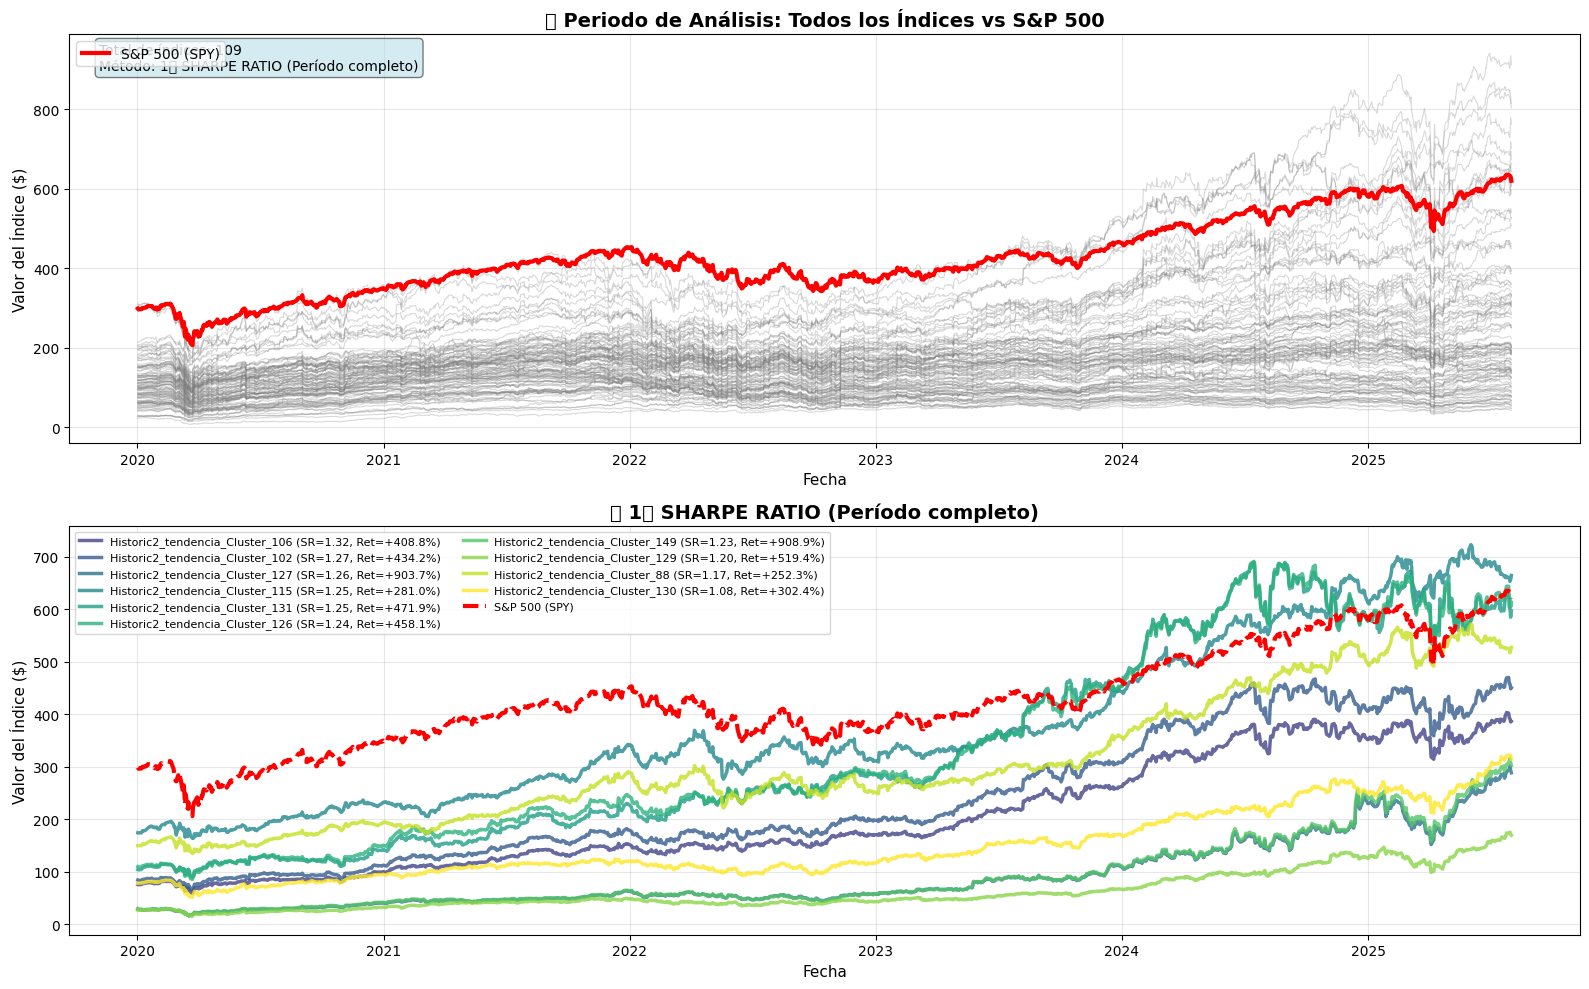


📊 COMPARACIÓN 1️⃣ SHARPE RATIO (Período completo) vs S&P 500:

📈 S&P 500 (SPY): +107.65%

🔝 TOP 10 ÍNDICES:
1. Historic2_tendencia_Cluster_106: Ret=+408.77% (vs SPY: +301.12%), SR=1.32, Vol=24.4%
2. Historic2_tendencia_Cluster_102: Ret=+434.15% (vs SPY: +326.50%), SR=1.27, Vol=26.4%
3. Historic2_tendencia_Cluster_127: Ret=+903.69% (vs SPY: +796.04%), SR=1.26, Vol=38.9%
4. Historic2_tendencia_Cluster_115: Ret=+281.02% (vs SPY: +173.37%), SR=1.25, Vol=20.9%
5. Historic2_tendencia_Cluster_131: Ret=+471.94% (vs SPY: +364.29%), SR=1.25, Vol=28.2%
6. Historic2_tendencia_Cluster_126: Ret=+458.08% (vs SPY: +350.43%), SR=1.24, Vol=28.0%
7. Historic2_tendencia_Cluster_149: Ret=+908.88% (vs SPY: +801.23%), SR=1.23, Vol=40.4%
8. Historic2_tendencia_Cluster_129: Ret=+519.41% (vs SPY: +411.76%), SR=1.20, Vol=31.5%
9. Historic2_tendencia_Cluster_88: Ret=+252.30% (vs SPY: +144.65%), SR=1.17, Vol=21.2%
10. Historic2_tendencia_Cluster_130: Ret=+302.36% (vs SPY: +194.71%), SR=1.08, Vol=26.3%

  VISUALIZ

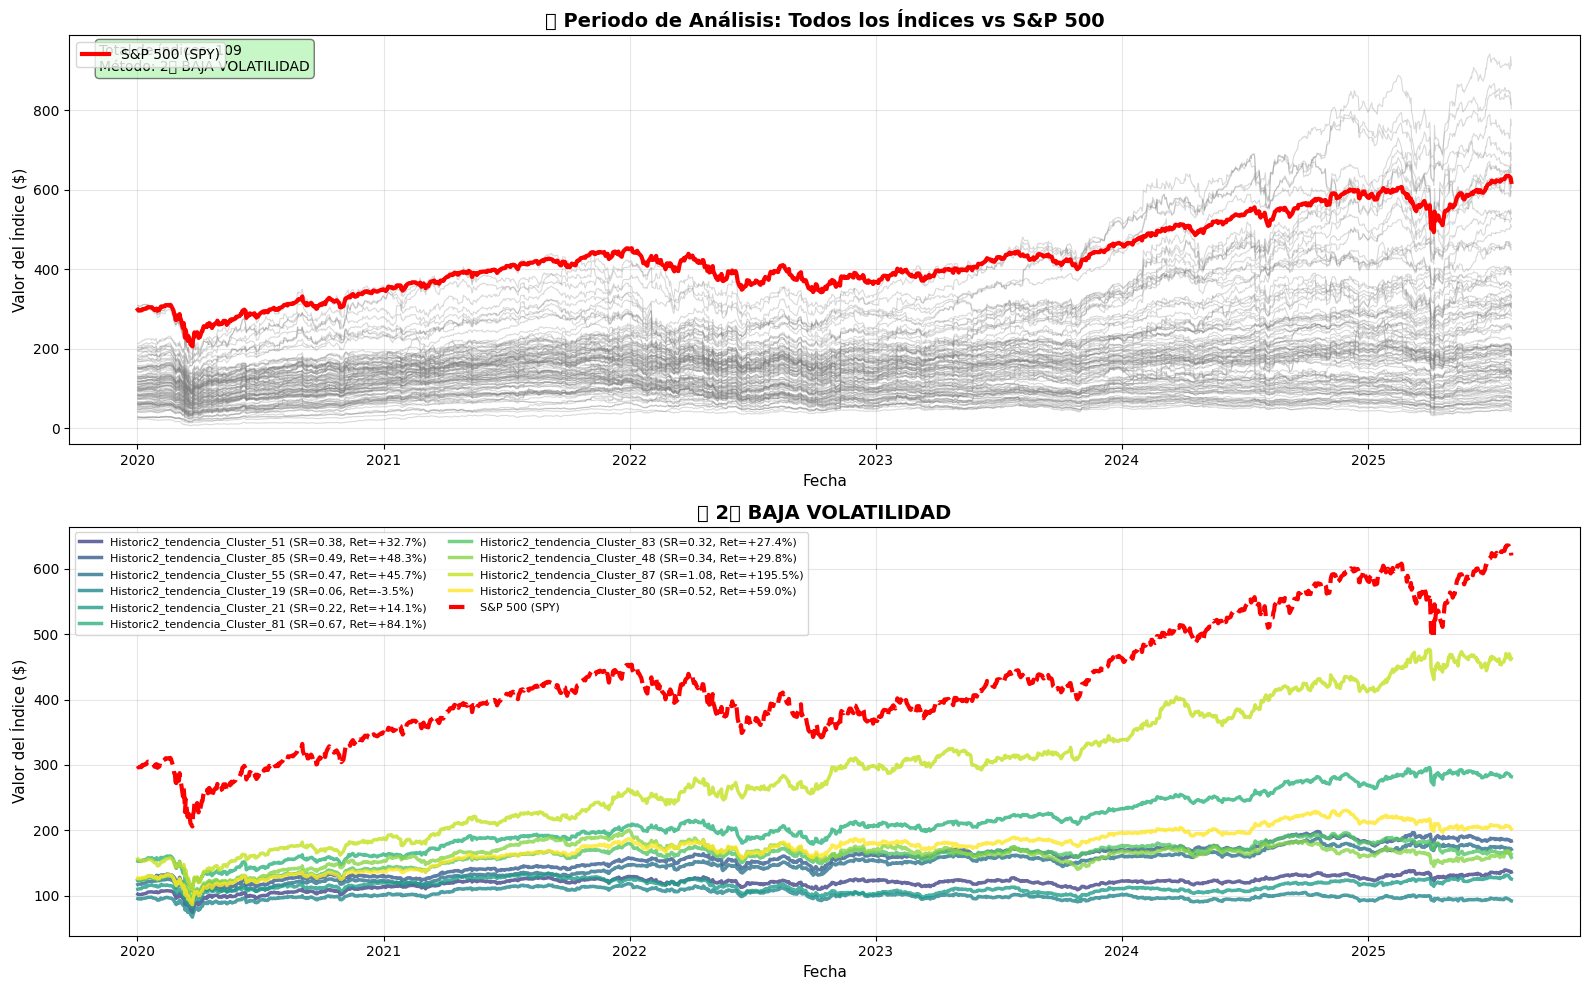


📊 COMPARACIÓN 2️⃣ BAJA VOLATILIDAD vs S&P 500:

📈 S&P 500 (SPY): +107.65%

🔝 TOP 10 ÍNDICES:
1. Historic2_tendencia_Cluster_51: Ret=+32.71% (vs SPY: -74.94%), SR=0.38, Vol=17.6%
2. Historic2_tendencia_Cluster_85: Ret=+48.33% (vs SPY: -59.32%), SR=0.49, Vol=17.7%
3. Historic2_tendencia_Cluster_55: Ret=+45.71% (vs SPY: -61.94%), SR=0.47, Vol=17.8%
4. Historic2_tendencia_Cluster_19: Ret=-3.47% (vs SPY: -111.12%), SR=0.06, Vol=18.6%
5. Historic2_tendencia_Cluster_21: Ret=+14.07% (vs SPY: -93.58%), SR=0.22, Vol=18.7%
6. Historic2_tendencia_Cluster_81: Ret=+84.11% (vs SPY: -23.54%), SR=0.67, Vol=19.2%
7. Historic2_tendencia_Cluster_83: Ret=+27.39% (vs SPY: -80.26%), SR=0.32, Vol=19.3%
8. Historic2_tendencia_Cluster_48: Ret=+29.83% (vs SPY: -77.82%), SR=0.34, Vol=19.7%
9. Historic2_tendencia_Cluster_87: Ret=+195.54% (vs SPY: +87.89%), SR=1.08, Vol=19.9%
10. Historic2_tendencia_Cluster_80: Ret=+59.00% (vs SPY: -48.65%), SR=0.52, Vol=20.0%

  VISUALIZACIÓN: 3️⃣ SCORE BALANCEADO


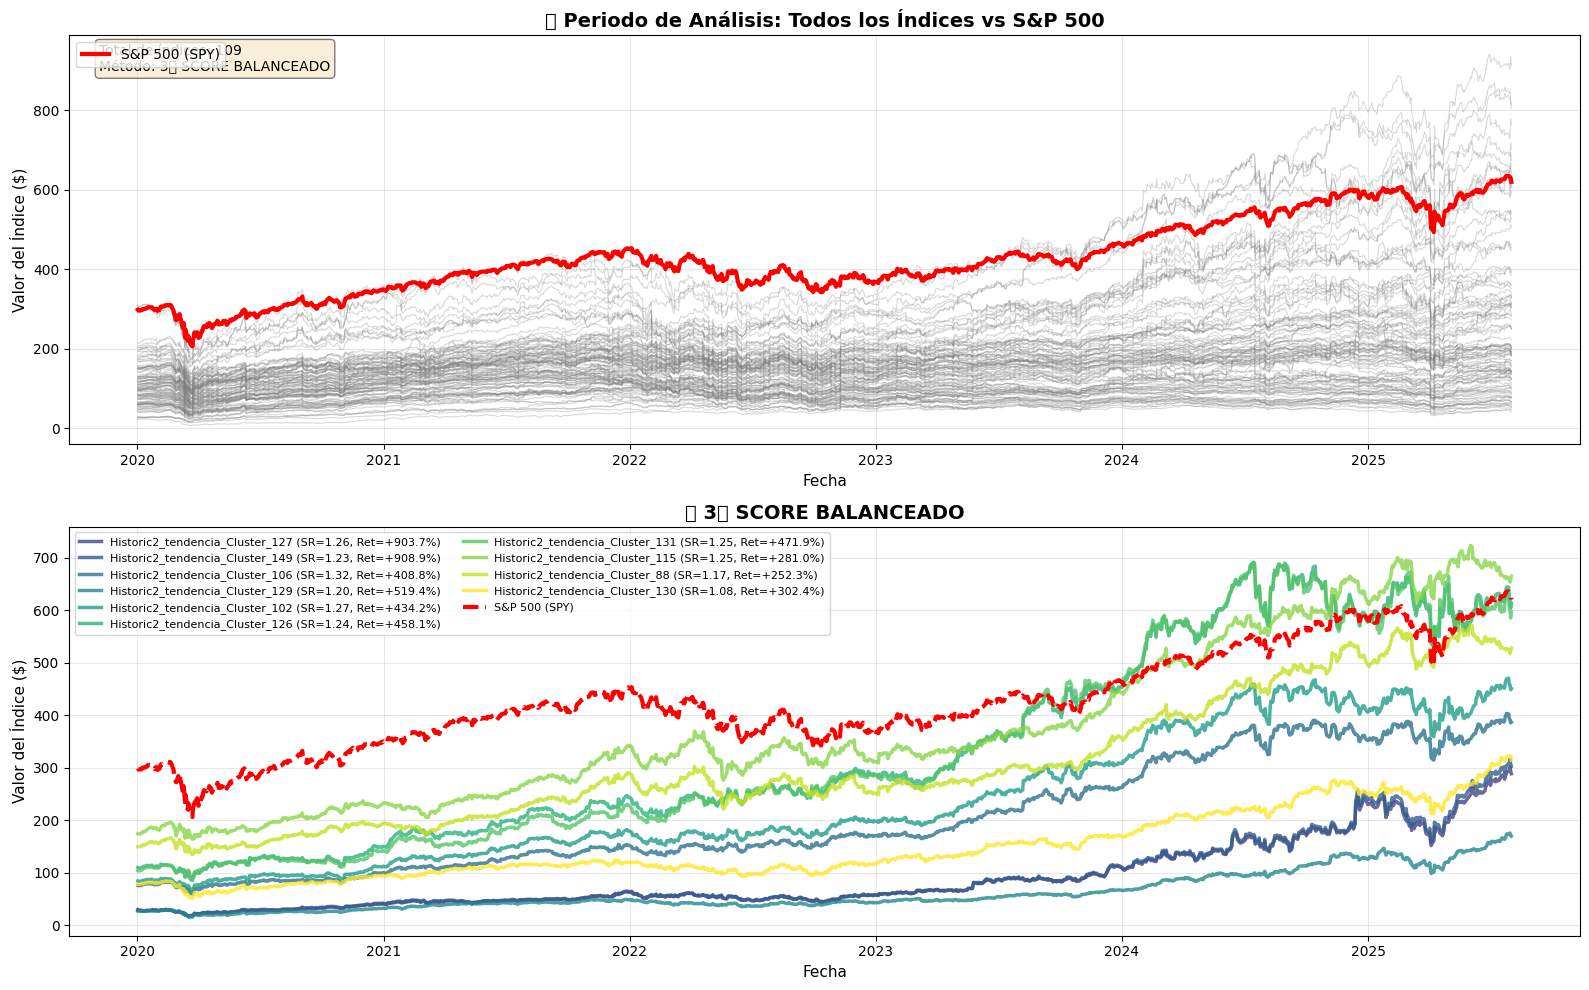


📊 COMPARACIÓN 3️⃣ SCORE BALANCEADO vs S&P 500:

📈 S&P 500 (SPY): +107.65%

🔝 TOP 10 ÍNDICES:
1. Historic2_tendencia_Cluster_127: Ret=+903.69% (vs SPY: +796.04%), SR=1.26, Vol=38.9%
2. Historic2_tendencia_Cluster_149: Ret=+908.88% (vs SPY: +801.23%), SR=1.23, Vol=40.4%
3. Historic2_tendencia_Cluster_106: Ret=+408.77% (vs SPY: +301.12%), SR=1.32, Vol=24.4%
4. Historic2_tendencia_Cluster_129: Ret=+519.41% (vs SPY: +411.76%), SR=1.20, Vol=31.5%
5. Historic2_tendencia_Cluster_102: Ret=+434.15% (vs SPY: +326.50%), SR=1.27, Vol=26.4%
6. Historic2_tendencia_Cluster_126: Ret=+458.08% (vs SPY: +350.43%), SR=1.24, Vol=28.0%
7. Historic2_tendencia_Cluster_131: Ret=+471.94% (vs SPY: +364.29%), SR=1.25, Vol=28.2%
8. Historic2_tendencia_Cluster_115: Ret=+281.02% (vs SPY: +173.37%), SR=1.25, Vol=20.9%
9. Historic2_tendencia_Cluster_88: Ret=+252.30% (vs SPY: +144.65%), SR=1.17, Vol=21.2%
10. Historic2_tendencia_Cluster_130: Ret=+302.36% (vs SPY: +194.71%), SR=1.08, Vol=26.3%

  VISUALIZACIÓN: 4️⃣ SCOR

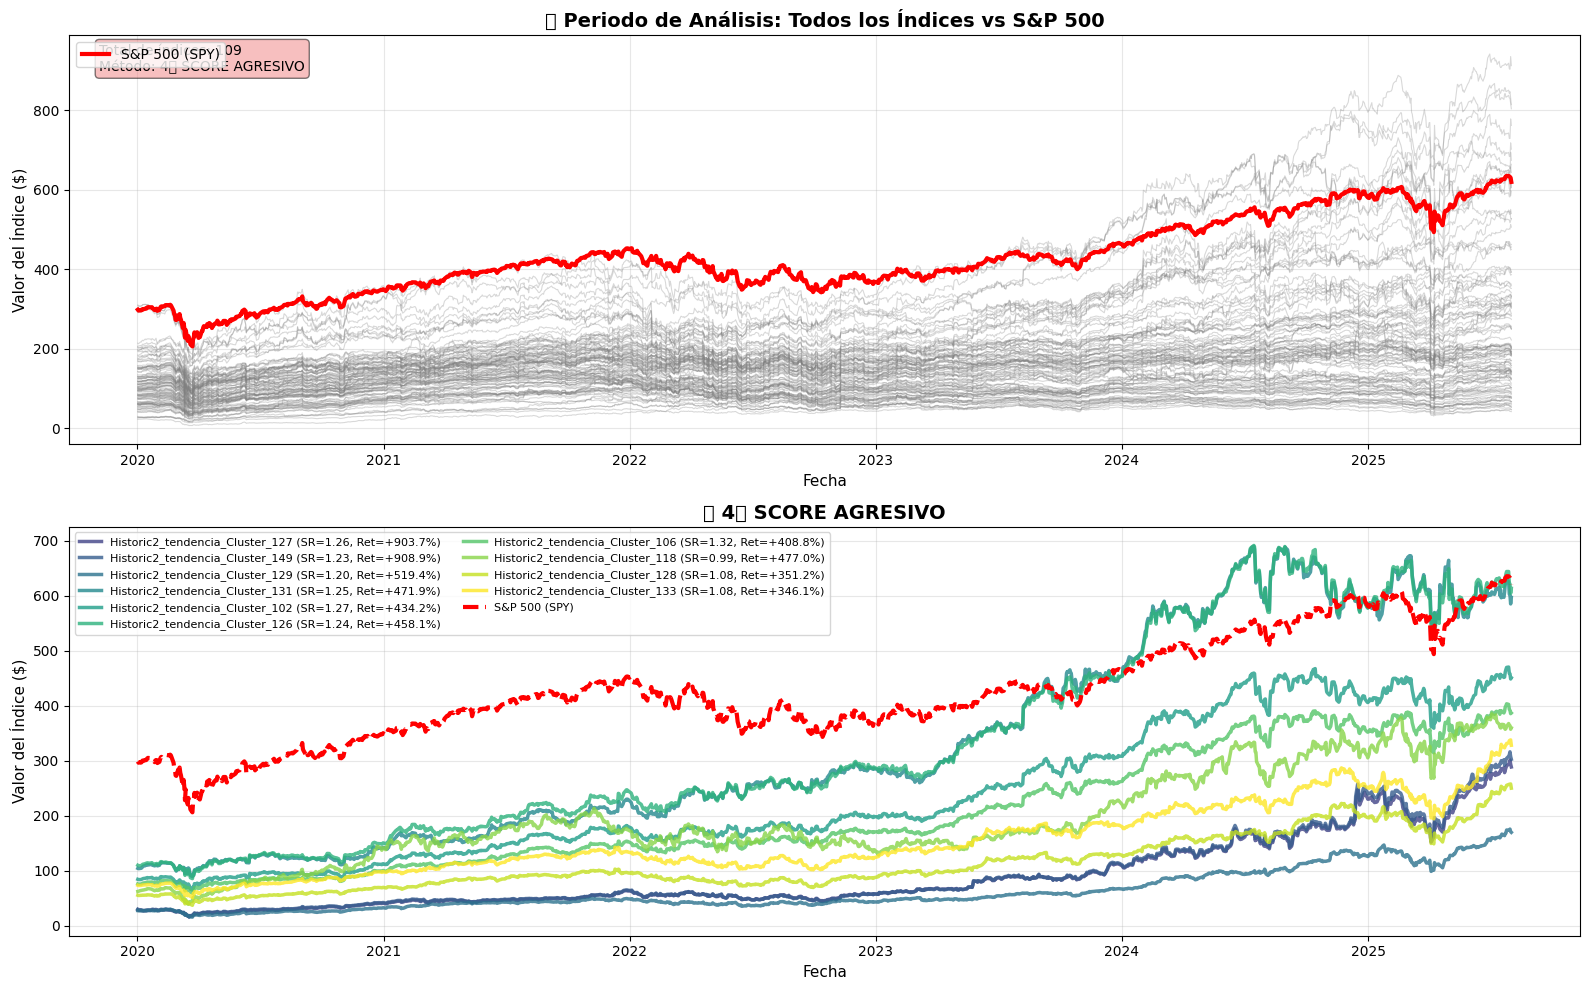


📊 COMPARACIÓN 4️⃣ SCORE AGRESIVO vs S&P 500:

📈 S&P 500 (SPY): +107.65%

🔝 TOP 10 ÍNDICES:
1. Historic2_tendencia_Cluster_127: Ret=+903.69% (vs SPY: +796.04%), SR=1.26, Vol=38.9%
2. Historic2_tendencia_Cluster_149: Ret=+908.88% (vs SPY: +801.23%), SR=1.23, Vol=40.4%
3. Historic2_tendencia_Cluster_129: Ret=+519.41% (vs SPY: +411.76%), SR=1.20, Vol=31.5%
4. Historic2_tendencia_Cluster_131: Ret=+471.94% (vs SPY: +364.29%), SR=1.25, Vol=28.2%
5. Historic2_tendencia_Cluster_102: Ret=+434.15% (vs SPY: +326.50%), SR=1.27, Vol=26.4%
6. Historic2_tendencia_Cluster_126: Ret=+458.08% (vs SPY: +350.43%), SR=1.24, Vol=28.0%
7. Historic2_tendencia_Cluster_106: Ret=+408.77% (vs SPY: +301.12%), SR=1.32, Vol=24.4%
8. Historic2_tendencia_Cluster_118: Ret=+476.99% (vs SPY: +369.34%), SR=0.99, Vol=39.9%
9. Historic2_tendencia_Cluster_128: Ret=+351.21% (vs SPY: +243.56%), SR=1.08, Vol=29.1%
10. Historic2_tendencia_Cluster_133: Ret=+346.12% (vs SPY: +238.46%), SR=1.08, Vol=28.6%

  VISUALIZACIÓN: 5️⃣ SCORE

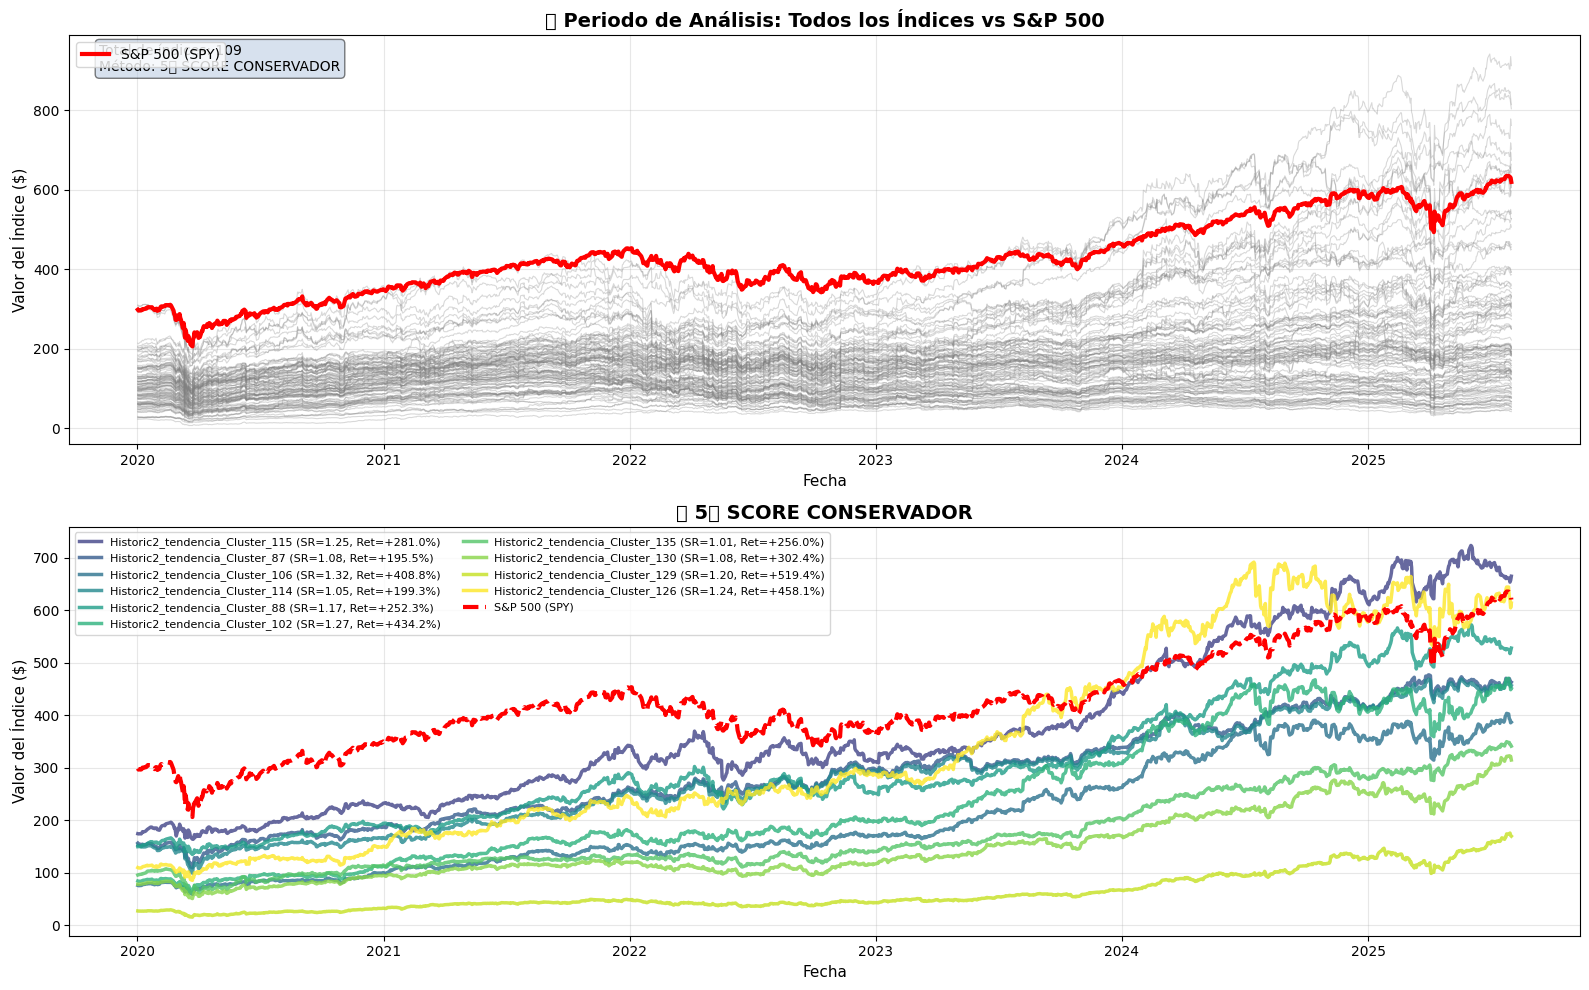


📊 COMPARACIÓN 5️⃣ SCORE CONSERVADOR vs S&P 500:

📈 S&P 500 (SPY): +107.65%

🔝 TOP 10 ÍNDICES:
1. Historic2_tendencia_Cluster_115: Ret=+281.02% (vs SPY: +173.37%), SR=1.25, Vol=20.9%
2. Historic2_tendencia_Cluster_87: Ret=+195.54% (vs SPY: +87.89%), SR=1.08, Vol=19.9%
3. Historic2_tendencia_Cluster_106: Ret=+408.77% (vs SPY: +301.12%), SR=1.32, Vol=24.4%
4. Historic2_tendencia_Cluster_114: Ret=+199.34% (vs SPY: +91.69%), SR=1.05, Vol=20.8%
5. Historic2_tendencia_Cluster_88: Ret=+252.30% (vs SPY: +144.65%), SR=1.17, Vol=21.2%
6. Historic2_tendencia_Cluster_102: Ret=+434.15% (vs SPY: +326.50%), SR=1.27, Vol=26.4%
7. Historic2_tendencia_Cluster_135: Ret=+255.98% (vs SPY: +148.33%), SR=1.01, Vol=25.9%
8. Historic2_tendencia_Cluster_130: Ret=+302.36% (vs SPY: +194.71%), SR=1.08, Vol=26.3%
9. Historic2_tendencia_Cluster_129: Ret=+519.41% (vs SPY: +411.76%), SR=1.20, Vol=31.5%
10. Historic2_tendencia_Cluster_126: Ret=+458.08% (vs SPY: +350.43%), SR=1.24, Vol=28.0%

  VISUALIZACIÓN: 6️⃣ SCORE 

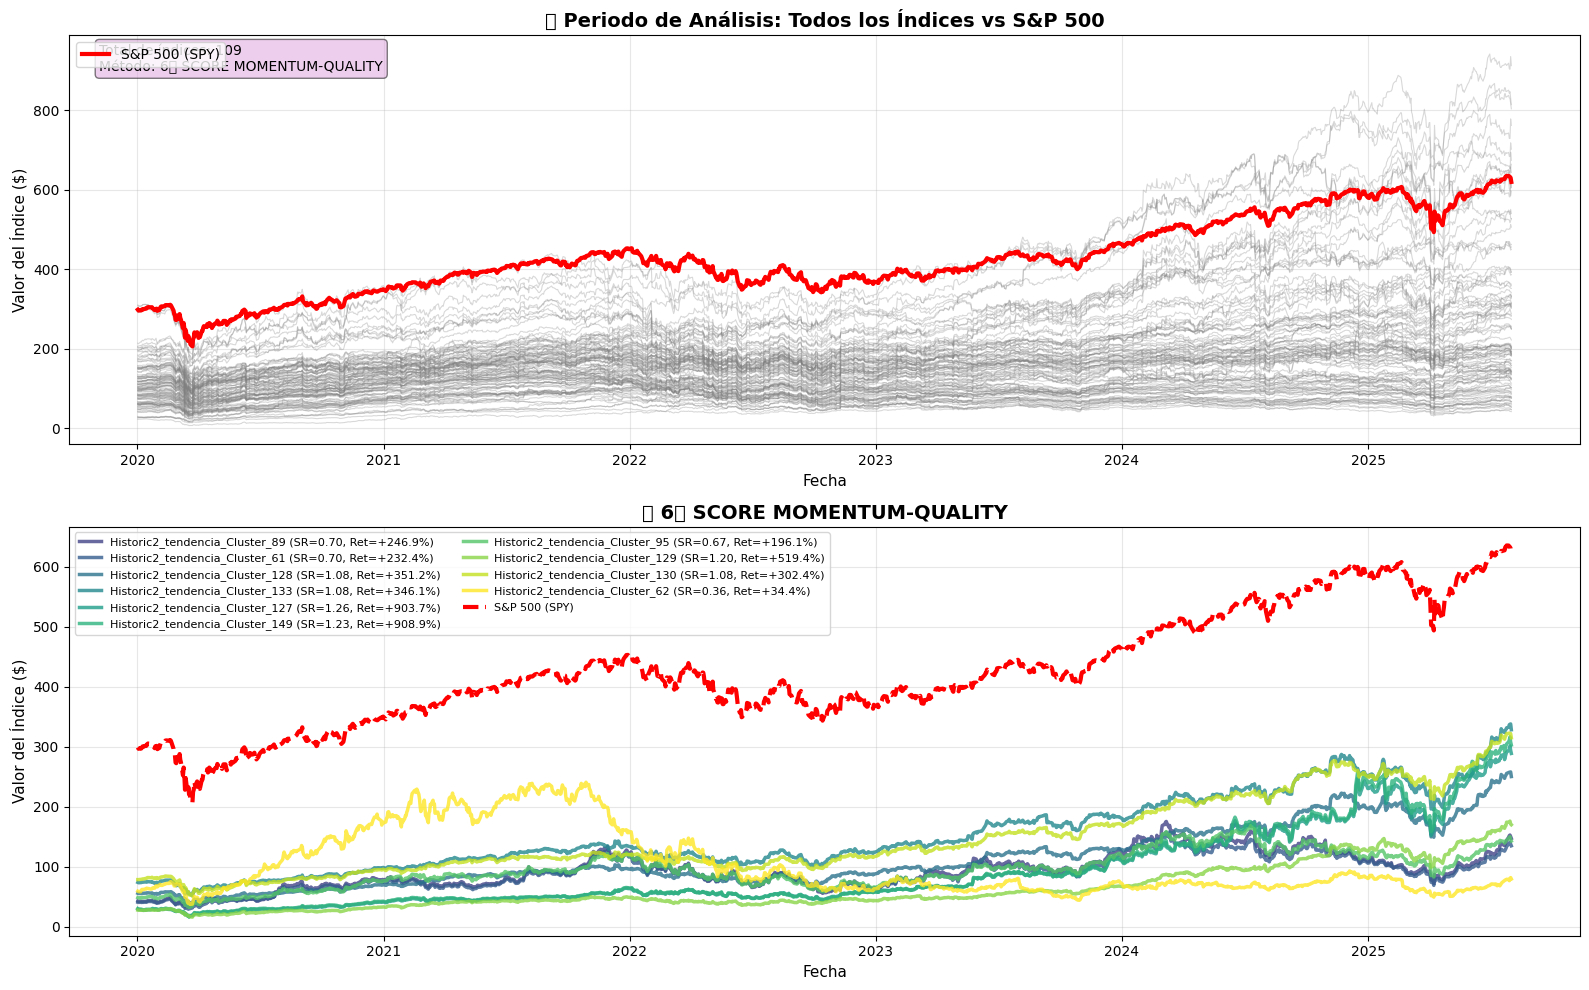


📊 COMPARACIÓN 6️⃣ SCORE MOMENTUM-QUALITY vs S&P 500:

📈 S&P 500 (SPY): +107.65%

🔝 TOP 10 ÍNDICES:
1. Historic2_tendencia_Cluster_89: Ret=+246.92% (vs SPY: +139.27%), SR=0.70, Vol=48.3%
2. Historic2_tendencia_Cluster_61: Ret=+232.40% (vs SPY: +124.75%), SR=0.70, Vol=45.0%
3. Historic2_tendencia_Cluster_128: Ret=+351.21% (vs SPY: +243.56%), SR=1.08, Vol=29.1%
4. Historic2_tendencia_Cluster_133: Ret=+346.12% (vs SPY: +238.46%), SR=1.08, Vol=28.6%
5. Historic2_tendencia_Cluster_127: Ret=+903.69% (vs SPY: +796.04%), SR=1.26, Vol=38.9%
6. Historic2_tendencia_Cluster_149: Ret=+908.88% (vs SPY: +801.23%), SR=1.23, Vol=40.4%
7. Historic2_tendencia_Cluster_95: Ret=+196.07% (vs SPY: +88.42%), SR=0.67, Vol=42.0%
8. Historic2_tendencia_Cluster_129: Ret=+519.41% (vs SPY: +411.76%), SR=1.20, Vol=31.5%
9. Historic2_tendencia_Cluster_130: Ret=+302.36% (vs SPY: +194.71%), SR=1.08, Vol=26.3%
10. Historic2_tendencia_Cluster_62: Ret=+34.43% (vs SPY: -73.22%), SR=0.36, Vol=52.0%

✅ VISUALIZACIONES COMPLET

In [49]:
# =======================================================
# 📊 VISUALIZACIONES POR CADA MÉTODO DE CALIFICACIÓN
# =======================================================

# SPY series para comparación
spy_series = SPY_analysis['SPY'] if isinstance(SPY_analysis, pd.DataFrame) else SPY_analysis
spy_return = ((spy_series.iloc[-1] / spy_series.iloc[0]) - 1) * 100

# Crear visualizaciones para cada método
for score_col, method_info in ranking_methods.items():
    print("\n" + "=" * 100)
    print(f"  VISUALIZACIÓN: {method_info['name']}")
    print("=" * 100)
    
    # Obtener Top 10 de este método
    top_10_clusters = all_rankings[score_col]
    
    # Crear figura con 2 subplots
    fig, axes = plt.subplots(2, 1, figsize=(16, 10))
    
    # --- SUBPLOT 1: TODOS LOS ÍNDICES + SPY ---
    ax1 = axes[0]
    
    # Graficar todos los índices en gris
    for cluster_name, cluster_data in cluster_indices.items():
        ax1.plot(cluster_data['index'], alpha=0.3, linewidth=0.8, color='gray')
    
    # SPY destacado
    ax1.plot(spy_series.index, spy_series, linewidth=3, color='red', 
             label='S&P 500 (SPY)', zorder=10)
    
    ax1.set_title('📊 Periodo de Análisis: Todos los Índices vs S&P 500', 
                  fontsize=14, fontweight='bold')
    ax1.set_xlabel('Fecha', fontsize=11)
    ax1.set_ylabel('Valor del Índice ($)', fontsize=11)
    ax1.legend(fontsize=10, loc='upper left')
    ax1.grid(True, alpha=0.3)
    
    # Agregar texto informativo
    ax1.text(0.02, 0.98, f'Total de índices: {len(cluster_indices)}\nMétodo: {method_info["name"]}', 
             transform=ax1.transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor=method_info['color'], alpha=0.5))
    
    # --- SUBPLOT 2: TOP 10 DE ESTE MÉTODO ---
    ax2 = axes[1]
    
    # Colores para los Top 10
    colors = plt.cm.viridis(np.linspace(0.2, 1, len(top_10_clusters)))
    
    for i, cluster_name in enumerate(top_10_clusters):
        cluster_data = cluster_indices[cluster_name]
        sharpe = cluster_data['metrics']['sharpe_ratio']
        retorno = cluster_data['metrics']['retorno_total'] * 100
        
        ax2.plot(cluster_data['index'], linewidth=2.5, alpha=0.8, color=colors[i],
                 label=f"{cluster_name} (SR={sharpe:.2f}, Ret={retorno:+.1f}%)")
    
    # SPY destacado
    ax2.plot(spy_series.index, spy_series, linewidth=3, color='red', 
             label='S&P 500 (SPY)', linestyle='--', zorder=10)
    
    ax2.set_title(f'🔝 {method_info["name"]}', 
                  fontsize=14, fontweight='bold')
    ax2.set_xlabel('Fecha', fontsize=11)
    ax2.set_ylabel('Valor del Índice ($)', fontsize=11)
    ax2.legend(fontsize=8, loc='upper left', ncol=2)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # --- ESTADÍSTICAS COMPARATIVAS ---
    print(f"\n📊 COMPARACIÓN {method_info['name']} vs S&P 500:")
    print(f"\n📈 S&P 500 (SPY): {spy_return:+.2f}%")
    
    print(f"\n🔝 TOP 10 ÍNDICES:")
    for i, cluster_name in enumerate(top_10_clusters, 1):
        metrics = cluster_indices[cluster_name]['metrics']
        sharpe = metrics['sharpe_ratio']
        retorno = metrics['retorno_total'] * 100
        diferencia = retorno - spy_return
        volatilidad = metrics['volatilidad'] * 100
        
        print(f"{i}. {cluster_name}: Ret={retorno:+.2f}% (vs SPY: {diferencia:+.2f}%), SR={sharpe:.2f}, Vol={volatilidad:.1f}%")

print("\n" + "=" * 100)
print("✅ VISUALIZACIONES COMPLETADAS PARA TODOS LOS MÉTODOS")
print("=" * 100)

In [50]:
###

## Validación

In [51]:
# Paso 1: Verificar que tenemos todos los datos necesarios
print("🔍 Verificando datos necesarios...")
print(f"   ✓ all_clusters: {len(all_clusters)} clusters")
print(f"   ✓ tickers_data: {tickers_data.shape}")
print(f"   ✓ market_caps: {len(market_caps)} tickers con capitalización")

# Paso 2: Crear índices para todos los clusters
cluster_indices = create_all_cluster_indices(
    all_clusters=all_clusters,
    data=validation_data,
    market_caps_dict=market_caps,
    start_value=1,
    normalized=True
)

# Paso 3: Crear tabla resumen con métricas DE VALIDACIÓN
print("\n" + "=" * 100)
print("  RESUMEN DE ÍNDICES VALIDACIÓN - PERFORMANCE OUT-OF-SAMPLE")
print("=" * 100)

summary_data_val = []
for cluster_name, cluster_data in cluster_indices.items():
    summary_data_val.append({
        'Cluster': cluster_name,
        'Tipo': cluster_data['type'],
        'Tickers': cluster_data['metrics']['num_tickers'],
        'Sharpe Ratio': cluster_data['metrics']['sharpe_ratio'],
        'Retorno (%)': cluster_data['metrics']['retorno_total'] * 100,
        'Volatilidad (%)': cluster_data['metrics']['volatilidad'] * 100,
        'Max Drawdown (%)': cluster_data['metrics']['max_drawdown'] * 100,
        'Tendencia': cluster_data['metrics']['tendencia'],
        'R²': cluster_data['metrics']['r_squared'],
        'Valor Inicial': cluster_data['metrics']['valor_inicial'],
        'Valor Final': cluster_data['metrics']['valor_final']
    })

summary_df_val = pd.DataFrame(summary_data_val)

print("\n\n📊 ESTADÍSTICAS GENERALES EN VALIDACIÓN:")
print(f"   ⭐ Sharpe Ratio promedio: {summary_df_val['Sharpe Ratio'].mean():.4f}")
print(f"   📊 R² promedio: {summary_df_val['R²'].mean():.4f}")
print(f"   💹 Retorno promedio: {summary_df_val['Retorno (%)'].mean():.2f}%")
print(f"   📊 Volatilidad promedio: {summary_df_val['Volatilidad (%)'].mean():.2f}%")
print(f"   📉 Max Drawdown promedio: {summary_df_val['Max Drawdown (%)'].mean():.2f}%")
print(f"   💰 Valor inicial promedio: ${summary_df_val['Valor Inicial'].mean():.2f}")
print(f"   💵 Valor final promedio: ${summary_df_val['Valor Final'].mean():.2f}")

🔍 Verificando datos necesarios...
   ✓ all_clusters: 109 clusters
   ✓ tickers_data: (1403, 487)
   ✓ market_caps: 487 tickers con capitalización

  RESUMEN DE ÍNDICES VALIDACIÓN - PERFORMANCE OUT-OF-SAMPLE


📊 ESTADÍSTICAS GENERALES EN VALIDACIÓN:
   ⭐ Sharpe Ratio promedio: 1.4892
   📊 R² promedio: 0.4572
   💹 Retorno promedio: 8.69%
   📊 Volatilidad promedio: 20.66%
   📉 Max Drawdown promedio: -7.09%
   💰 Valor inicial promedio: $1.00
   💵 Valor final promedio: $1.09

  RESUMEN DE ÍNDICES VALIDACIÓN - PERFORMANCE OUT-OF-SAMPLE


📊 ESTADÍSTICAS GENERALES EN VALIDACIÓN:
   ⭐ Sharpe Ratio promedio: 1.4892
   📊 R² promedio: 0.4572
   💹 Retorno promedio: 8.69%
   📊 Volatilidad promedio: 20.66%
   📉 Max Drawdown promedio: -7.09%
   💰 Valor inicial promedio: $1.00
   💵 Valor final promedio: $1.09


In [52]:
# =======================================================
# 📊 EVALUACIÓN DE CADA MÉTODO EN VALIDACIÓN (Out-of-Sample)
# =======================================================

# SPY de validación para comparación
spy_series_val = SPY_validation['SPY'] if isinstance(SPY_validation, pd.DataFrame) else SPY_validation
spy_return_val = ((spy_series_val.iloc[-1] / spy_series_val.iloc[0]) - 1) * 100

print("\n" + "=" * 100)
print("  COMPARACIÓN DE MÉTODOS: ANÁLISIS vs VALIDACIÓN")
print("=" * 100)
print(f"\n📈 S&P 500 en Validación: {spy_return_val:+.2f}%\n")

# Resultados de cada método
comparison_results = {}

for score_col, method_info in ranking_methods.items():
    print("=" * 100)
    print(f"  {method_info['name']}")
    print("=" * 100)
    
    # Top 10 seleccionados en ANÁLISIS
    top_10_analysis = all_rankings[score_col]
    
    # Performance de esos Top 10 en VALIDACIÓN
    validation_metrics = []
    for cluster_name in top_10_analysis:
        if cluster_name in cluster_indices:
            val_metrics = cluster_indices[cluster_name]['metrics']
            validation_metrics.append({
                'Cluster': cluster_name,
                'Sharpe Val': val_metrics['sharpe_ratio'],
                'Retorno Val (%)': val_metrics['retorno_total'] * 100,
                'Volatilidad Val (%)': val_metrics['volatilidad'] * 100,
                'Max DD Val (%)': val_metrics['max_drawdown'] * 100
            })
    
    val_df = pd.DataFrame(validation_metrics)
    
    # Mostrar resultados
    print(f"\n📊 Performance en VALIDACIÓN de los Top 10 seleccionados en ANÁLISIS:")
    print(val_df.to_string(index=False))
    
    # Estadísticas agregadas
    avg_sharpe_val = val_df['Sharpe Val'].mean()
    avg_ret_val = val_df['Retorno Val (%)'].mean()
    avg_vol_val = val_df['Volatilidad Val (%)'].mean()
    
    print(f"\n📈 ESTADÍSTICAS AGREGADAS EN VALIDACIÓN:")
    print(f"   ⭐ Sharpe Ratio promedio: {avg_sharpe_val:.4f}")
    print(f"   💹 Retorno promedio: {avg_ret_val:+.2f}%")
    print(f"   📊 Volatilidad promedio: {avg_vol_val:.2f}%")
    print(f"   🎯 vs SPY: {avg_ret_val - spy_return_val:+.2f}%")
    print(f"   🏆 Clusters que superan SPY: {sum(val_df['Retorno Val (%)'] > spy_return_val)}/10")
    
    # Guardar para comparación final
    comparison_results[score_col] = {
        'method_name': method_info['name'],
        'avg_sharpe_val': avg_sharpe_val,
        'avg_return_val': avg_ret_val,
        'avg_vol_val': avg_vol_val,
        'vs_spy': avg_ret_val - spy_return_val,
        'clusters_beat_spy': sum(val_df['Retorno Val (%)'] > spy_return_val),
        'top_10_clusters': top_10_analysis
    }
    print()

# =======================================================
# 🏆 COMPARACIÓN FINAL: ¿QUÉ MÉTODO FUNCIONA MEJOR?
# =======================================================

print("\n" + "=" * 120)
print("  🏆 RANKING DE MÉTODOS POR PERFORMANCE EN VALIDACIÓN")
print("=" * 120)

results_summary = []
for score_col, results in comparison_results.items():
    results_summary.append({
        'Método': results['method_name'],
        'Ret Val (%)': results['avg_return_val'],
        'vs SPY (%)': results['vs_spy'],
        'Sharpe Val': results['avg_sharpe_val'],
        'Vol Val (%)': results['avg_vol_val'],
        'Beat SPY': f"{results['clusters_beat_spy']}/10"
    })

results_df = pd.DataFrame(results_summary)
results_df = results_df.sort_values('Ret Val (%)', ascending=False)

print("\n📊 COMPARACIÓN DE TODOS LOS MÉTODOS (ordenado por Retorno en Validación):")
print(results_df.to_string(index=False))

print("\n" + "=" * 120)
print("  CONCLUSIONES:")
print("=" * 120)

best_method = results_df.iloc[0]
print(f"\n🥇 MEJOR MÉTODO POR RETORNO: {best_method['Método']}")
print(f"   Retorno promedio en validación: {best_method['Ret Val (%)']:+.2f}%")
print(f"   Superioridad vs SPY: {best_method['vs SPY (%)']:+.2f}%")
print(f"   Clusters que superan SPY: {best_method['Beat SPY']}")

best_sharpe_idx = results_df['Sharpe Val'].idxmax()
best_sharpe_method = results_df.loc[best_sharpe_idx]
print(f"\n🥇 MEJOR MÉTODO POR SHARPE RATIO: {best_sharpe_method['Método']}")
print(f"   Sharpe promedio en validación: {best_sharpe_method['Sharpe Val']:.4f}")
print(f"   Retorno promedio: {best_sharpe_method['Ret Val (%)']:+.2f}%")

best_consistency_idx = results_df['Beat SPY'].apply(lambda x: int(x.split('/')[0])).idxmax()
best_consistency_method = results_df.loc[best_consistency_idx]
print(f"\n🥇 MEJOR MÉTODO POR CONSISTENCIA: {best_consistency_method['Método']}")
print(f"   Clusters que superan SPY: {best_consistency_method['Beat SPY']}")
print(f"   Retorno promedio: {best_consistency_method['Ret Val (%)']:+.2f}%")

print("\n" + "=" * 120)


  COMPARACIÓN DE MÉTODOS: ANÁLISIS vs VALIDACIÓN

📈 S&P 500 en Validación: +10.01%

  1️⃣ SHARPE RATIO (Período completo)

📊 Performance en VALIDACIÓN de los Top 10 seleccionados en ANÁLISIS:
                        Cluster  Sharpe Val  Retorno Val (%)  Volatilidad Val (%)  Max DD Val (%)
Historic2_tendencia_Cluster_106    1.326571         7.958781            25.115434       -9.776924
Historic2_tendencia_Cluster_102    1.635748        10.890272            27.141962      -10.132403
Historic2_tendencia_Cluster_127    2.431882        24.839192            39.000743       -9.809829
Historic2_tendencia_Cluster_115   -0.074808        -0.523972            14.255857       -5.447605
Historic2_tendencia_Cluster_131    1.330472        10.686926            34.651824      -15.223830
Historic2_tendencia_Cluster_126    1.798120        13.404041            30.093391      -12.661775
Historic2_tendencia_Cluster_149    2.344657        24.976964            40.950839      -10.933819
Historic2_tendencia_Clu


  VALIDACIÓN: 1️⃣ SHARPE RATIO (Período completo)

📊 Top 10 seleccionados en ANÁLISIS - Performance en VALIDACIÓN:
   1. Historic2_tendencia_Cluster_106: Ret=+7.96%, Sharpe=1.33
   2. Historic2_tendencia_Cluster_102: Ret=+10.89%, Sharpe=1.64
   3. Historic2_tendencia_Cluster_127: Ret=+24.84%, Sharpe=2.43
   4. Historic2_tendencia_Cluster_115: Ret=-0.52%, Sharpe=-0.07
   5. Historic2_tendencia_Cluster_131: Ret=+10.69%, Sharpe=1.33
   6. Historic2_tendencia_Cluster_126: Ret=+13.40%, Sharpe=1.80
   7. Historic2_tendencia_Cluster_149: Ret=+24.98%, Sharpe=2.34
   8. Historic2_tendencia_Cluster_129: Ret=+2.64%, Sharpe=0.53
   9. Historic2_tendencia_Cluster_88: Ret=-3.38%, Sharpe=-0.90
   10. Historic2_tendencia_Cluster_130: Ret=+2.08%, Sharpe=0.40


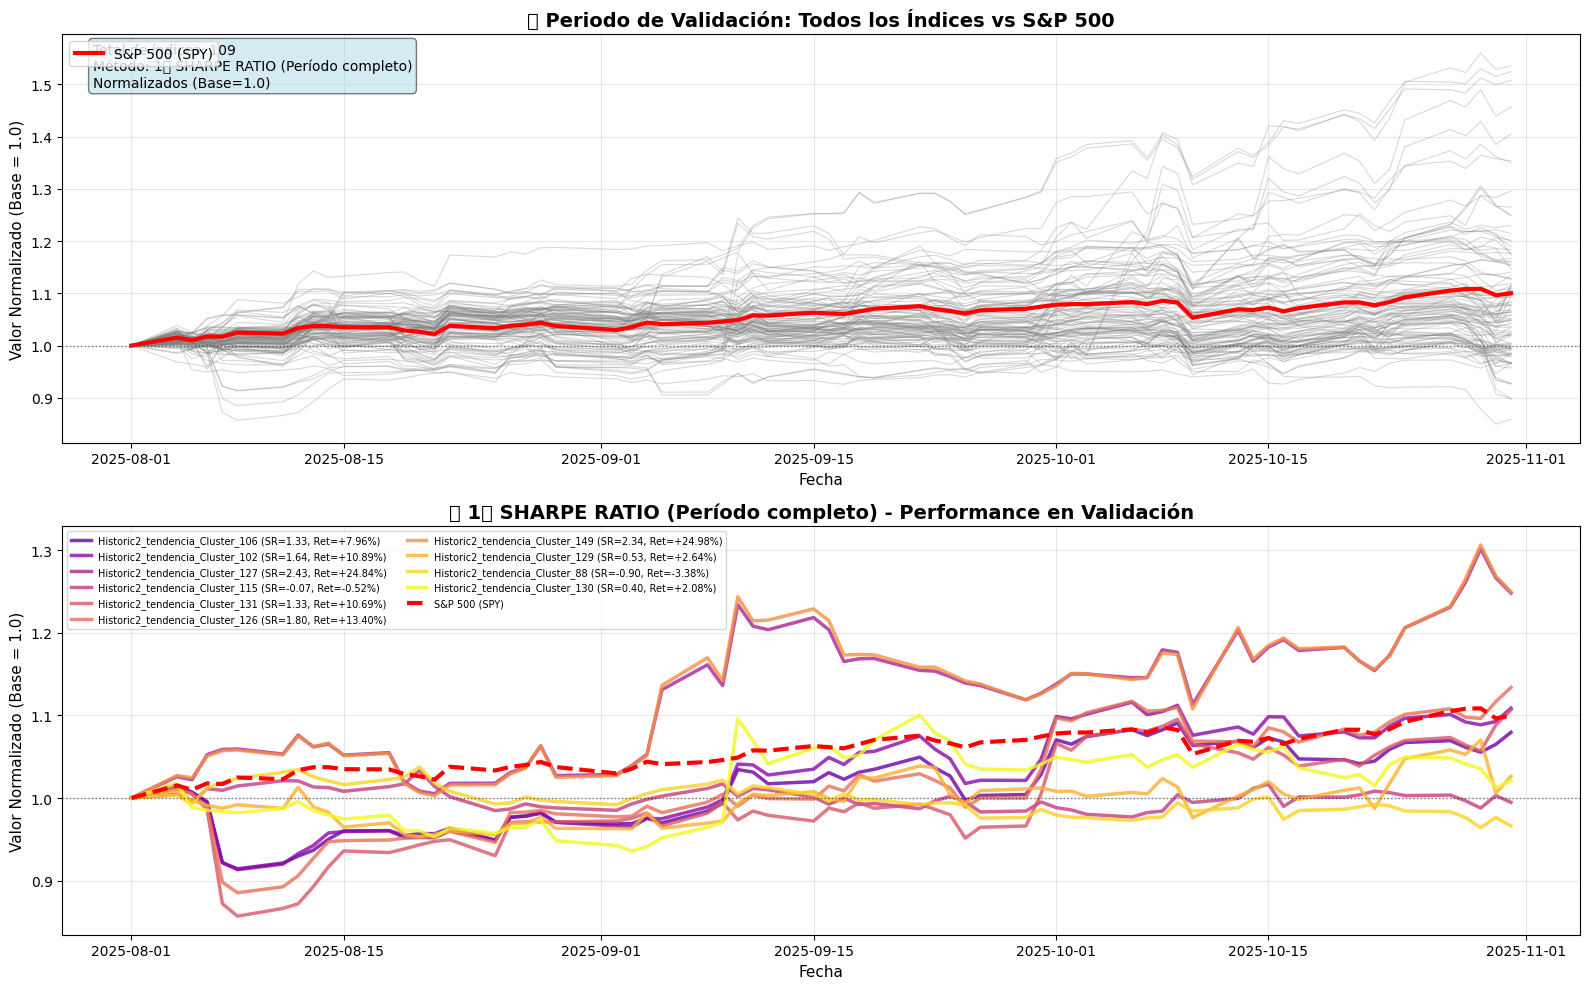


  VALIDACIÓN: 2️⃣ BAJA VOLATILIDAD

📊 Top 10 seleccionados en ANÁLISIS - Performance en VALIDACIÓN:
   1. Historic2_tendencia_Cluster_51: Ret=+2.74%, Sharpe=1.15
   2. Historic2_tendencia_Cluster_85: Ret=+0.21%, Sharpe=0.14
   3. Historic2_tendencia_Cluster_55: Ret=+2.38%, Sharpe=1.12
   4. Historic2_tendencia_Cluster_19: Ret=+0.43%, Sharpe=0.20
   5. Historic2_tendencia_Cluster_21: Ret=+5.00%, Sharpe=1.62
   6. Historic2_tendencia_Cluster_81: Ret=-0.57%, Sharpe=-0.18
   7. Historic2_tendencia_Cluster_83: Ret=+7.68%, Sharpe=2.58
   8. Historic2_tendencia_Cluster_48: Ret=+10.43%, Sharpe=2.71
   9. Historic2_tendencia_Cluster_87: Ret=-3.35%, Sharpe=-0.98
   10. Historic2_tendencia_Cluster_80: Ret=+4.75%, Sharpe=1.79


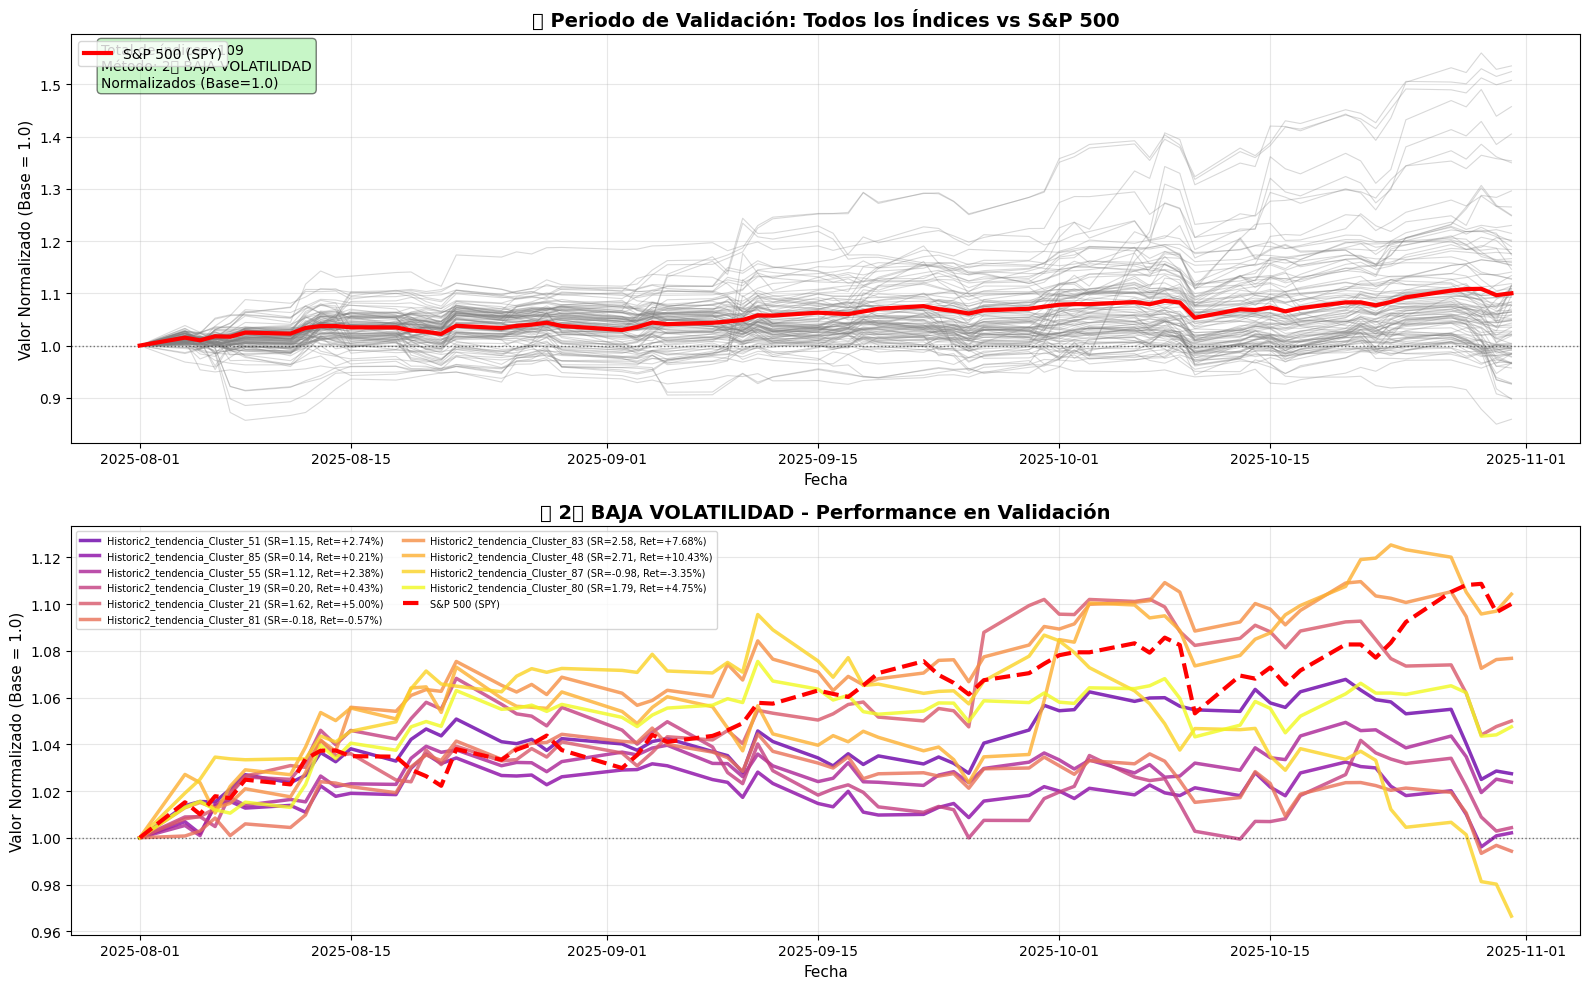


  VALIDACIÓN: 3️⃣ SCORE BALANCEADO

📊 Top 10 seleccionados en ANÁLISIS - Performance en VALIDACIÓN:
   1. Historic2_tendencia_Cluster_127: Ret=+24.84%, Sharpe=2.43
   2. Historic2_tendencia_Cluster_149: Ret=+24.98%, Sharpe=2.34
   3. Historic2_tendencia_Cluster_106: Ret=+7.96%, Sharpe=1.33
   4. Historic2_tendencia_Cluster_129: Ret=+2.64%, Sharpe=0.53
   5. Historic2_tendencia_Cluster_102: Ret=+10.89%, Sharpe=1.64
   6. Historic2_tendencia_Cluster_126: Ret=+13.40%, Sharpe=1.80
   7. Historic2_tendencia_Cluster_131: Ret=+10.69%, Sharpe=1.33
   8. Historic2_tendencia_Cluster_115: Ret=-0.52%, Sharpe=-0.07
   9. Historic2_tendencia_Cluster_88: Ret=-3.38%, Sharpe=-0.90
   10. Historic2_tendencia_Cluster_130: Ret=+2.08%, Sharpe=0.40


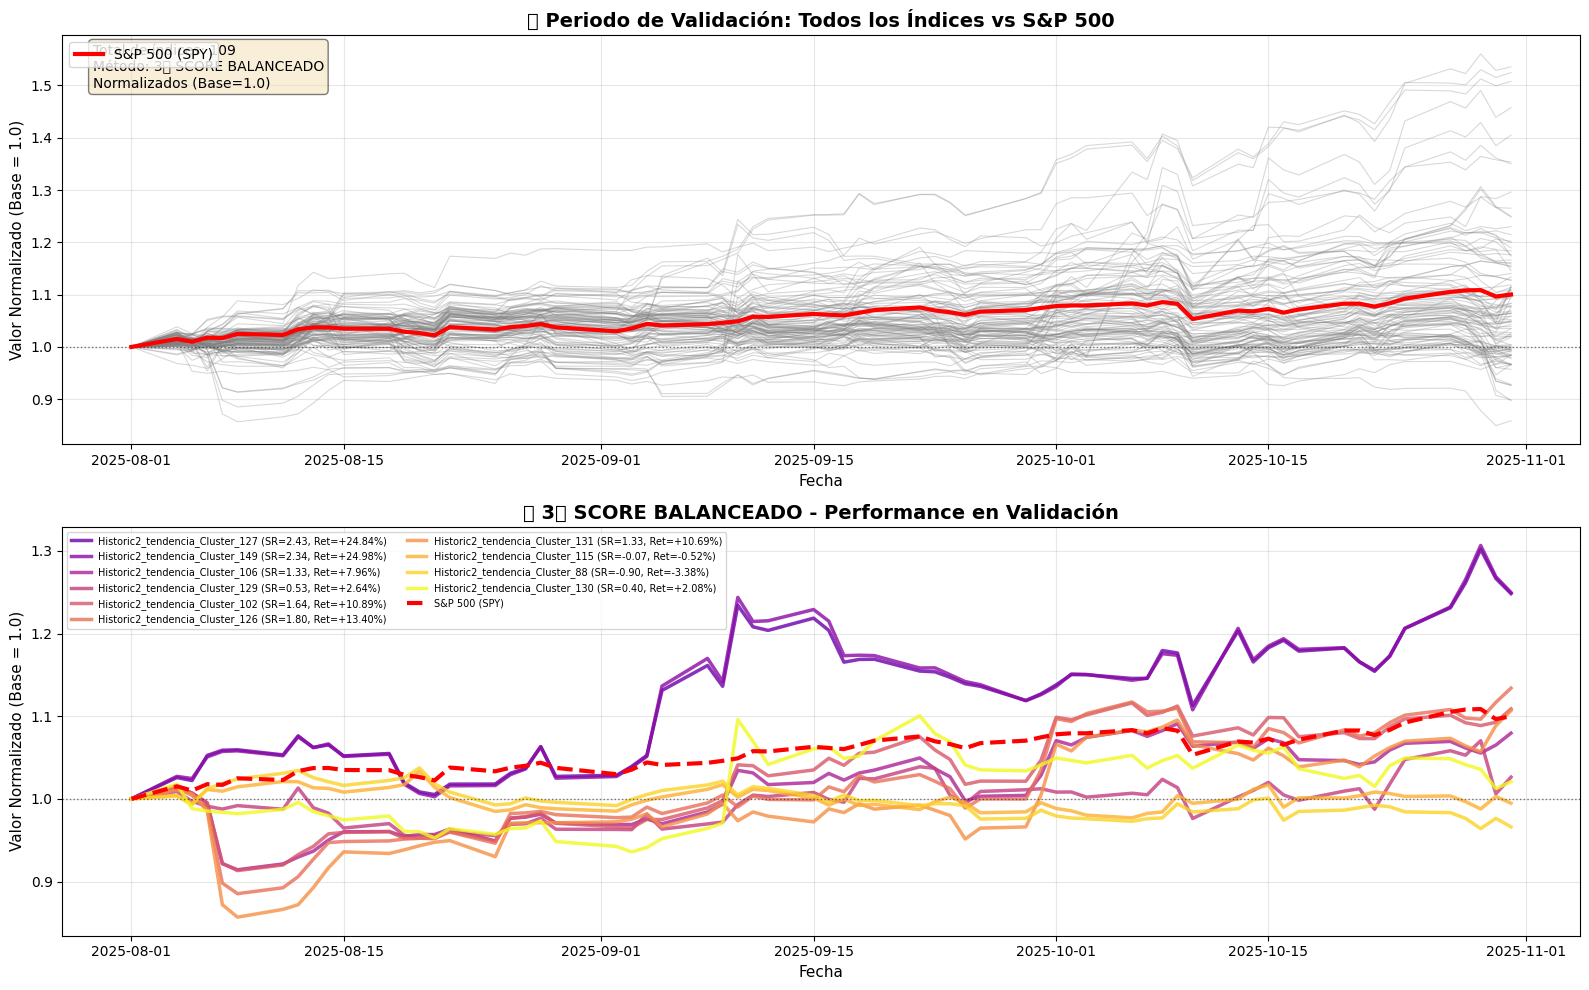


  VALIDACIÓN: 4️⃣ SCORE AGRESIVO

📊 Top 10 seleccionados en ANÁLISIS - Performance en VALIDACIÓN:
   1. Historic2_tendencia_Cluster_127: Ret=+24.84%, Sharpe=2.43
   2. Historic2_tendencia_Cluster_149: Ret=+24.98%, Sharpe=2.34
   3. Historic2_tendencia_Cluster_129: Ret=+2.64%, Sharpe=0.53
   4. Historic2_tendencia_Cluster_131: Ret=+10.69%, Sharpe=1.33
   5. Historic2_tendencia_Cluster_102: Ret=+10.89%, Sharpe=1.64
   6. Historic2_tendencia_Cluster_126: Ret=+13.40%, Sharpe=1.80
   7. Historic2_tendencia_Cluster_106: Ret=+7.96%, Sharpe=1.33
   8. Historic2_tendencia_Cluster_118: Ret=+18.92%, Sharpe=2.42
   9. Historic2_tendencia_Cluster_128: Ret=+5.89%, Sharpe=0.69
   10. Historic2_tendencia_Cluster_133: Ret=+1.86%, Sharpe=0.37


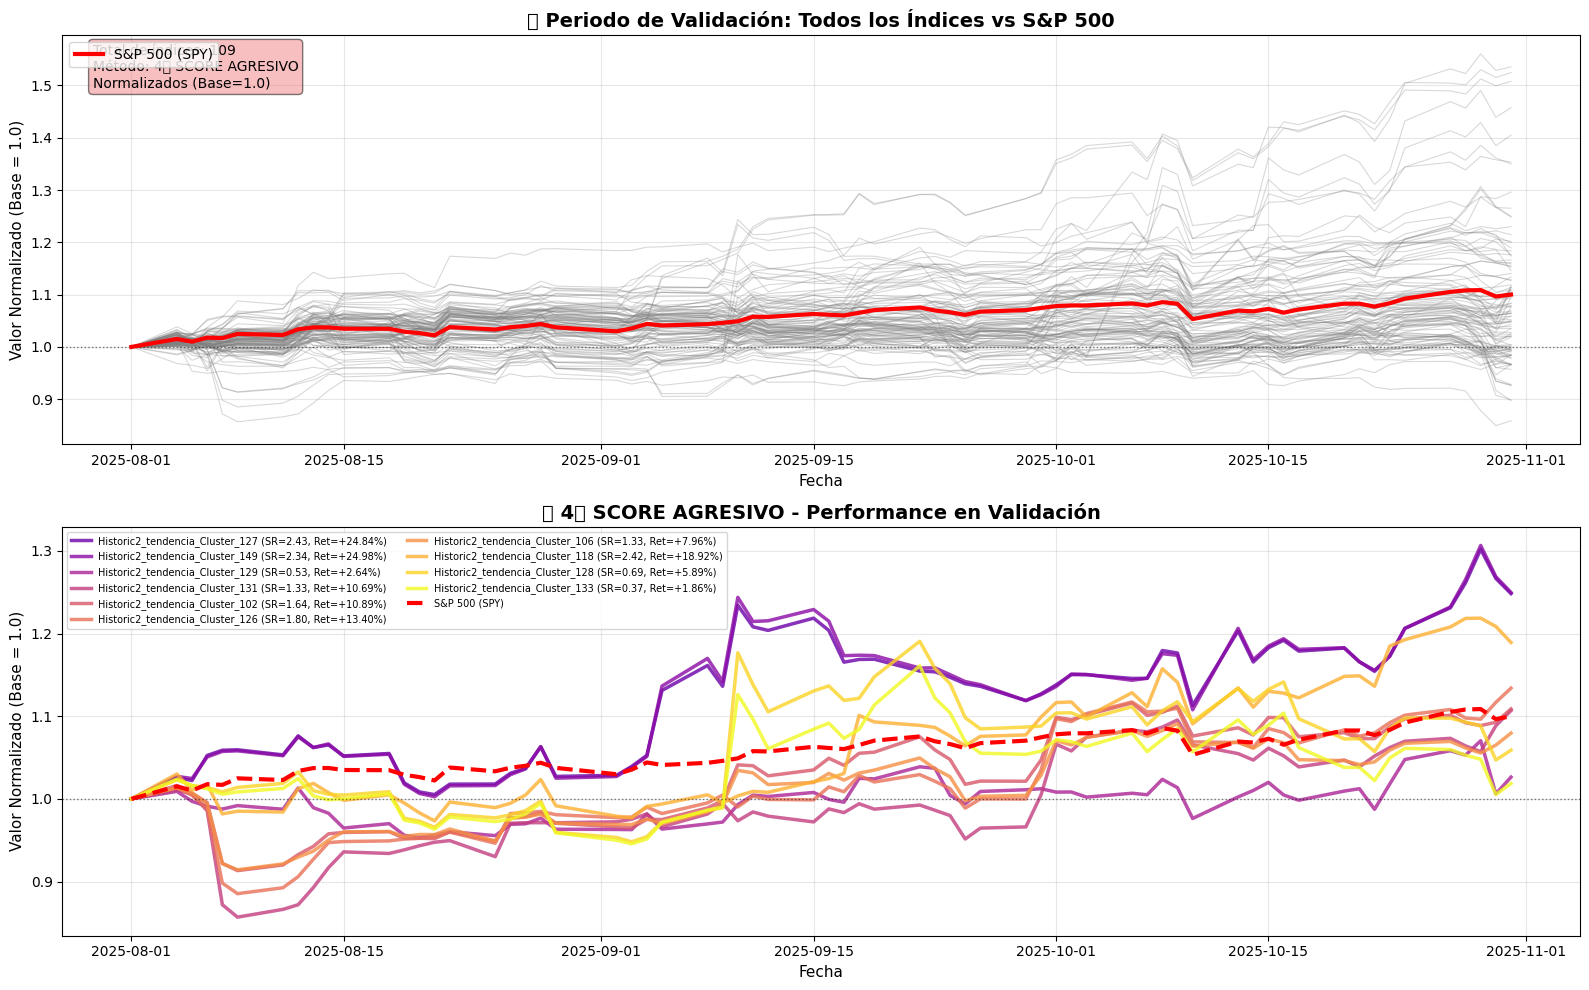


  VALIDACIÓN: 5️⃣ SCORE CONSERVADOR

📊 Top 10 seleccionados en ANÁLISIS - Performance en VALIDACIÓN:
   1. Historic2_tendencia_Cluster_115: Ret=-0.52%, Sharpe=-0.07
   2. Historic2_tendencia_Cluster_87: Ret=-3.35%, Sharpe=-0.98
   3. Historic2_tendencia_Cluster_106: Ret=+7.96%, Sharpe=1.33
   4. Historic2_tendencia_Cluster_114: Ret=-2.09%, Sharpe=-0.54
   5. Historic2_tendencia_Cluster_88: Ret=-3.38%, Sharpe=-0.90
   6. Historic2_tendencia_Cluster_102: Ret=+10.89%, Sharpe=1.64
   7. Historic2_tendencia_Cluster_135: Ret=-3.19%, Sharpe=-0.66
   8. Historic2_tendencia_Cluster_130: Ret=+2.08%, Sharpe=0.40
   9. Historic2_tendencia_Cluster_129: Ret=+2.64%, Sharpe=0.53
   10. Historic2_tendencia_Cluster_126: Ret=+13.40%, Sharpe=1.80


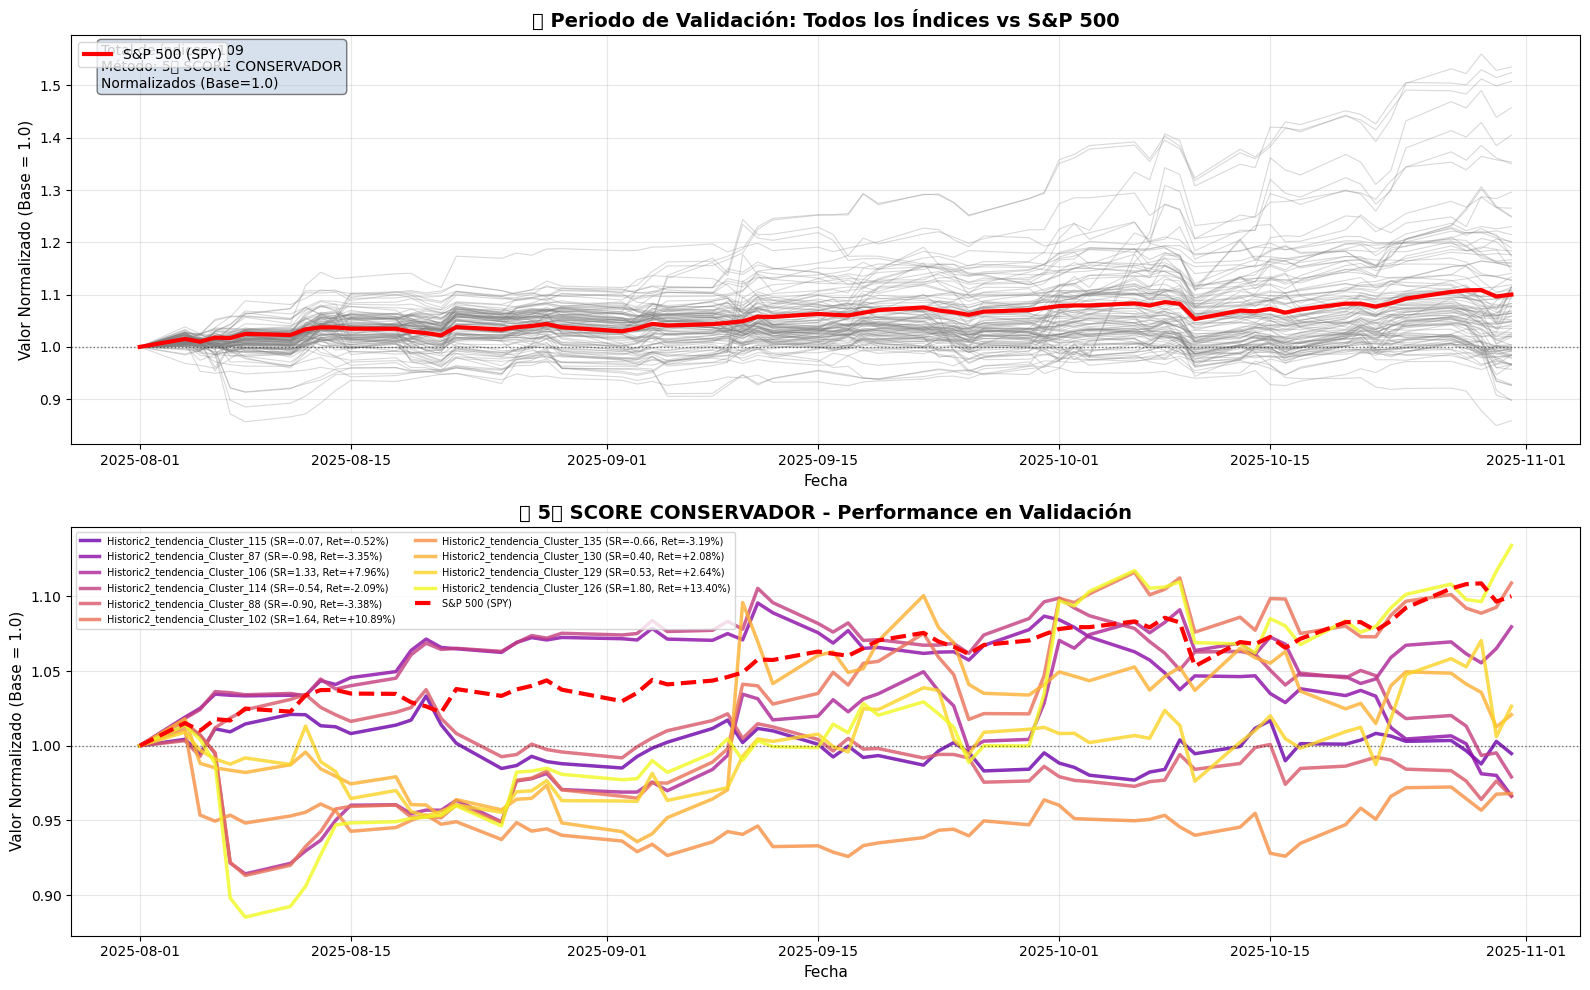


  VALIDACIÓN: 6️⃣ SCORE MOMENTUM-QUALITY

📊 Top 10 seleccionados en ANÁLISIS - Performance en VALIDACIÓN:
   1. Historic2_tendencia_Cluster_89: Ret=+45.75%, Sharpe=2.68
   2. Historic2_tendencia_Cluster_61: Ret=+40.51%, Sharpe=2.66
   3. Historic2_tendencia_Cluster_128: Ret=+5.89%, Sharpe=0.69
   4. Historic2_tendencia_Cluster_133: Ret=+1.86%, Sharpe=0.37
   5. Historic2_tendencia_Cluster_127: Ret=+24.84%, Sharpe=2.43
   6. Historic2_tendencia_Cluster_149: Ret=+24.98%, Sharpe=2.34
   7. Historic2_tendencia_Cluster_95: Ret=+53.55%, Sharpe=4.44
   8. Historic2_tendencia_Cluster_129: Ret=+2.64%, Sharpe=0.53
   9. Historic2_tendencia_Cluster_130: Ret=+2.08%, Sharpe=0.40
   10. Historic2_tendencia_Cluster_62: Ret=-3.36%, Sharpe=-0.27


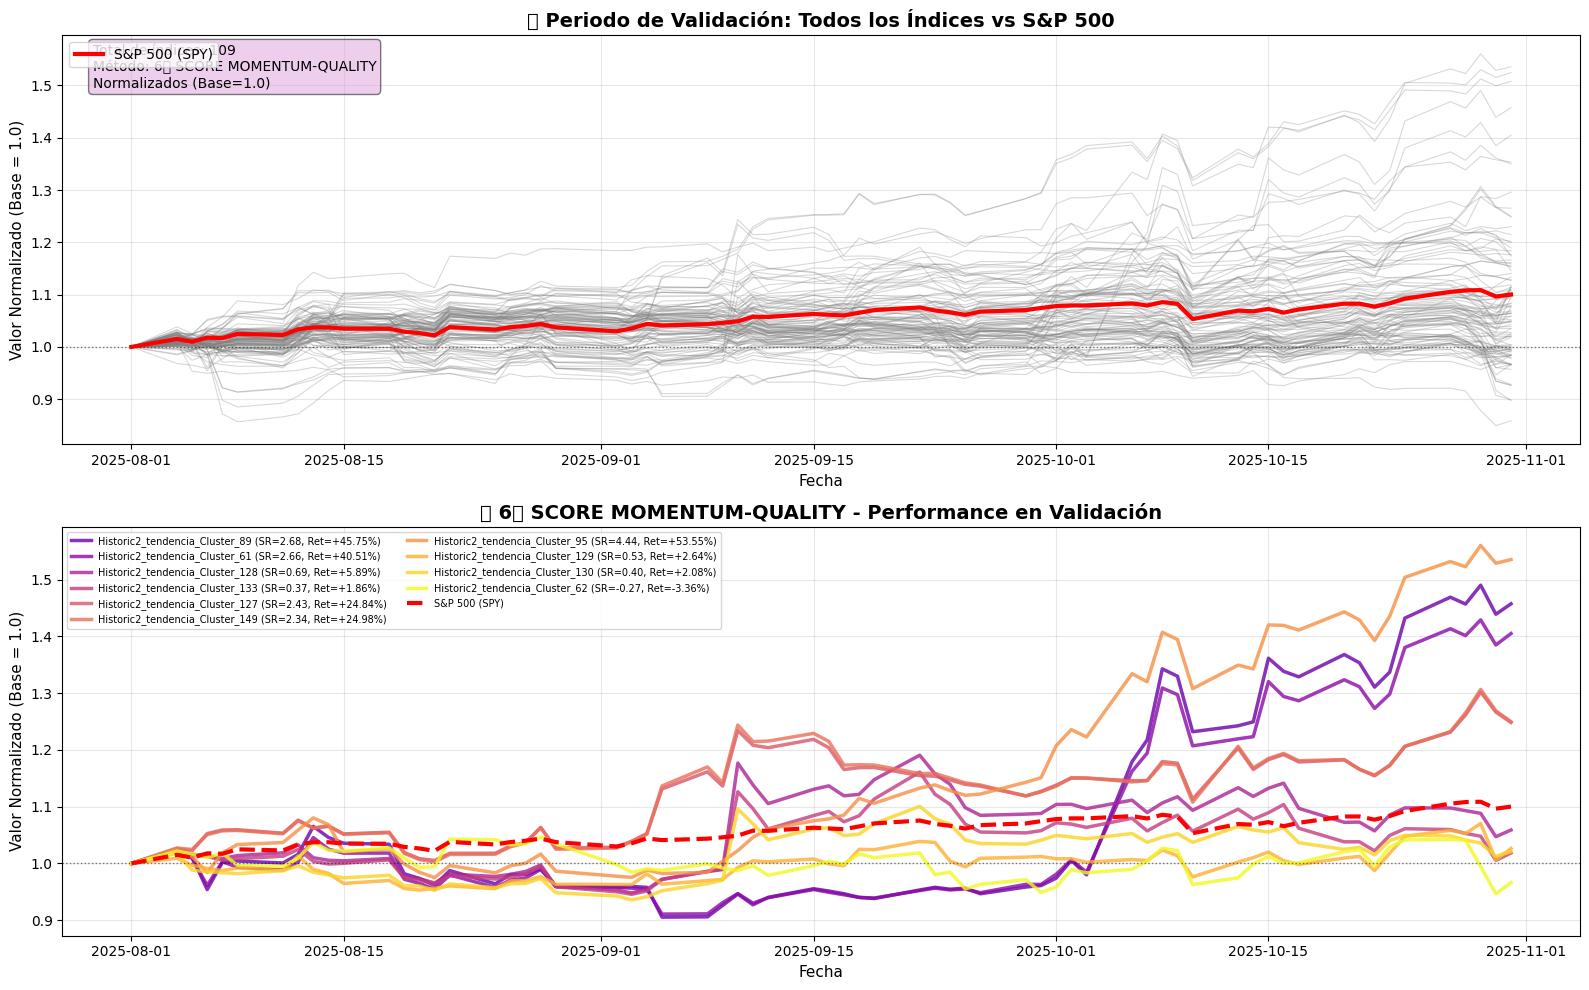


✅ VISUALIZACIONES DE VALIDACIÓN COMPLETADAS PARA TODOS LOS MÉTODOS

📊 TOP 10 ÍNDICES EN VALIDACIÓN (ORDENADOS POR SHARPE Y RETORNO)

🏆 TOP 10 POR SHARPE RATIO:
                        Cluster  Sharpe Ratio  Retorno (%)  Volatilidad (%)  Max Drawdown (%)
 Historic2_tendencia_Cluster_67      6.302578    50.787248        26.277052         -5.510740
 Historic2_tendencia_Cluster_33      6.249661    52.451845        27.235386         -5.709388
Historic2_tendencia_Cluster_111      5.085853    20.180159        14.452433         -3.807195
Historic2_tendencia_Cluster_100      4.775617    35.368155        25.709133         -6.755567
 Historic2_tendencia_Cluster_40      4.706690    23.005670        17.677198         -5.566222
 Historic2_tendencia_Cluster_84      4.505015    15.326744        12.651530         -3.388480
 Historic2_tendencia_Cluster_52      4.483286    18.373268        15.082296         -3.813303
 Historic2_tendencia_Cluster_95      4.440056    53.545890        39.898420         -9.

In [53]:
# =======================================================
# 📊 VISUALIZACIONES EN VALIDACIÓN POR CADA MÉTODO
# =======================================================

import matplotlib.pyplot as plt

# SPY de validación (normalizado)
spy_series_val = SPY_validation['SPY'] if isinstance(SPY_validation, pd.DataFrame) else SPY_validation
spy_normalized = spy_series_val / spy_series_val.iloc[0]

# Crear visualizaciones para cada método en VALIDACIÓN
for score_col, method_info in ranking_methods.items():
    print("\n" + "=" * 100)
    print(f"  VALIDACIÓN: {method_info['name']}")
    print("=" * 100)
    
    # Top 10 seleccionados en ANÁLISIS
    top_10_analysis = comparison_results[score_col]['top_10_clusters']
    
    # Crear figura con 2 subplots
    fig, axes = plt.subplots(2, 1, figsize=(16, 10))
    
    # --- SUBPLOT 1: TODOS LOS ÍNDICES + SPY ---
    ax1 = axes[0]
    
    # Graficar todos los índices en gris
    for cluster_name, cluster_data in cluster_indices.items():
        ax1.plot(cluster_data['index'], alpha=0.3, linewidth=0.8, color='gray')
    
    # SPY destacado
    ax1.plot(spy_normalized.index, spy_normalized, linewidth=3, color='red', 
             label='S&P 500 (SPY)', zorder=10)
    
    ax1.set_title('📊 Periodo de Validación: Todos los Índices vs S&P 500', 
                  fontsize=14, fontweight='bold')
    ax1.set_xlabel('Fecha', fontsize=11)
    ax1.set_ylabel('Valor Normalizado (Base = 1.0)', fontsize=11)
    ax1.legend(fontsize=10, loc='upper left')
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=1.0, color='black', linestyle=':', linewidth=1, alpha=0.5)
    
    # Agregar texto informativo
    ax1.text(0.02, 0.98, f'Total de índices: {len(cluster_indices)}\nMétodo: {method_info["name"]}\nNormalizados (Base=1.0)', 
             transform=ax1.transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor=method_info['color'], alpha=0.5))
    
    # --- SUBPLOT 2: TOP 10 DE ESTE MÉTODO (Performance en Validación) ---
    ax2 = axes[1]
    
    colors = plt.cm.plasma(np.linspace(0.2, 1, len(top_10_analysis)))
    
    print(f"\n📊 Top 10 seleccionados en ANÁLISIS - Performance en VALIDACIÓN:")
    for i, cluster_name in enumerate(top_10_analysis):
        if cluster_name in cluster_indices:
            cluster_data = cluster_indices[cluster_name]
            retorno_val = cluster_data['metrics']['retorno_total'] * 100
            sharpe_val = cluster_data['metrics']['sharpe_ratio']
            
            ax2.plot(cluster_data['index'], linewidth=2.5, alpha=0.8, color=colors[i],
                     label=f"{cluster_name} (SR={sharpe_val:.2f}, Ret={retorno_val:+.2f}%)")
            
            print(f"   {i+1}. {cluster_name}: Ret={retorno_val:+.2f}%, Sharpe={sharpe_val:.2f}")
        else:
            print(f"   ⚠️  {cluster_name}: No encontrado")
    
    # SPY destacado
    ax2.plot(spy_normalized.index, spy_normalized, linewidth=3, color='red', 
             label='S&P 500 (SPY)', linestyle='--', zorder=10)
    
    ax2.set_title(f'🔝 {method_info["name"]} - Performance en Validación', 
                  fontsize=14, fontweight='bold')
    ax2.set_xlabel('Fecha', fontsize=11)
    ax2.set_ylabel('Valor Normalizado (Base = 1.0)', fontsize=11)
    ax2.legend(fontsize=7, loc='upper left', ncol=2)
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=1.0, color='black', linestyle=':', linewidth=1, alpha=0.5)
    
    plt.tight_layout()
    plt.show()

print("\n" + "=" * 100)
print("✅ VISUALIZACIONES DE VALIDACIÓN COMPLETADAS PARA TODOS LOS MÉTODOS")
print("=" * 100)

# =======================================================
# 📊 TABLA: TOP 10 POR SHARPE Y RETORNO EN VALIDACIÓN
# =======================================================

print("\n" + "="*80)
print("📊 TOP 10 ÍNDICES EN VALIDACIÓN (ORDENADOS POR SHARPE Y RETORNO)")
print("="*80)

# Crear DataFrame con métricas de validación
validation_ranking = []
for cluster_name, cluster_data in cluster_indices.items():
    metrics = cluster_data['metrics']
    validation_ranking.append({
        'Cluster': cluster_name,
        'Retorno (%)': metrics['retorno_total'] * 100,
        'Sharpe Ratio': metrics['sharpe_ratio'],
        'Volatilidad (%)': metrics['volatilidad'] * 100,
        'Max Drawdown (%)': metrics['max_drawdown'] * 100,
        'Valor Inicial': metrics['valor_inicial'],
        'Valor Final': metrics['valor_final'],
        'Tickers': metrics['num_tickers']
    })

validation_df = pd.DataFrame(validation_ranking)

# Ordenar por Sharpe Ratio (descendente)
validation_df_sharpe = validation_df.sort_values('Sharpe Ratio', ascending=False)

# Ordenar por Retorno (descendente)
validation_df_retorno = validation_df.sort_values('Retorno (%)', ascending=False)

# Calcular retorno de SPY en validación
spy_return_val = ((spy_series_val.iloc[-1] / spy_series_val.iloc[0]) - 1) * 100

print("\n🏆 TOP 10 POR SHARPE RATIO:")
print("="*80)
print(validation_df_sharpe.head(10)[['Cluster', 'Sharpe Ratio', 'Retorno (%)', 'Volatilidad (%)', 'Max Drawdown (%)']].to_string(index=False))

print("\n\n🏆 TOP 10 POR RETORNO:")
print("="*80)
print(validation_df_retorno.head(10)[['Cluster', 'Retorno (%)', 'Sharpe Ratio', 'Volatilidad (%)', 'Max Drawdown (%)']].to_string(index=False))

# Estadísticas comparativas
print("\n" + "="*80)
print("📊 COMPARACIÓN VS S&P 500")
print("="*80)

print(f"\n📈 S&P 500 (SPY) en Validación:")
print(f"   Retorno: {spy_return_val:+.2f}%")

# Comparar Top 10 seleccionados en análisis vs SPY
print(f"\n📊 TOP 10 SELECCIONADOS EN ANÁLISIS:")
top_10_performance = []
for cluster_name in top_10_clusters:
    if cluster_name in cluster_indices:
        metrics = cluster_indices[cluster_name]['metrics']
        retorno = metrics['retorno_total'] * 100
        diferencia = retorno - spy_return_val
        top_10_performance.append({
            'Cluster': cluster_name,
            'Retorno': retorno,
            'vs SPY': diferencia
        })

top_10_perf_df = pd.DataFrame(top_10_performance).sort_values('Retorno', ascending=False)
print(top_10_perf_df.to_string(index=False))

# Análisis de rendimiento
superan_spy = sum(1 for p in top_10_performance if p['vs SPY'] > 0)
promedio_retorno = sum(p['Retorno'] for p in top_10_performance) / len(top_10_performance)
promedio_diferencia = promedio_retorno - spy_return_val

print(f"\n{'='*80}")
print(f"📊 RESUMEN DE PERFORMANCE:")
print(f"   Índices que superan SPY: {superan_spy}/{len(top_10_performance)}")
print(f"   Retorno promedio Top 10: {promedio_retorno:+.2f}%")
print(f"   Diferencia promedio vs SPY: {promedio_diferencia:+.2f}%")
print(f"{'='*80}")

# =======================================================
# 📊 TABLA: COMPARACIÓN ANÁLISIS vs VALIDACIÓN
# =======================================================

print("\n" + "="*80)
print("📊 COMPARACIÓN: TOP 10 SELECCIONADOS POR SHARPE RATIO - ANÁLISIS vs VALIDACIÓN")
print("="*80)

# Recrear índices del periodo de análisis para comparar métricas
cluster_indices_analysis = create_all_cluster_indices(
    all_clusters=all_clusters,
    data=tickers_data,
    market_caps_dict=market_caps,
    start_value=1,
    normalized=True
)

# Crear DataFrame comparativo
comparison_data = []
for cluster_name in top_10_clusters:
    if cluster_name in cluster_indices_analysis and cluster_name in cluster_indices:
        # Métricas de análisis
        metrics_analysis = cluster_indices_analysis[cluster_name]['metrics']
        # Métricas de validación
        metrics_validation = cluster_indices[cluster_name]['metrics']
        
        comparison_data.append({
            'Cluster': cluster_name,
            'Sharpe Análisis': metrics_analysis['sharpe_ratio'],  # ✅ CRITERIO DE SELECCIÓN
            'Retorno Análisis (%)': metrics_analysis['retorno_total'] * 100,
            'Vol Análisis (%)': metrics_analysis['volatilidad'] * 100,
            'Sharpe Validación': metrics_validation['sharpe_ratio'],
            'Retorno Validación (%)': metrics_validation['retorno_total'] * 100,
            'Vol Validación (%)': metrics_validation['volatilidad'] * 100,
            'Δ Sharpe': metrics_validation['sharpe_ratio'] - metrics_analysis['sharpe_ratio'],
            'Tendencia Análisis (60d)': metrics_analysis['tendencia'],
            'Tendencia Validación': metrics_validation['tendencia']
        })

comparison_df = pd.DataFrame(comparison_data)

# Mostrar tabla completa
print("\n📋 Tabla Comparativa Completa:")
print(comparison_df.to_string(index=False))

# Estadísticas agregadas
print("\n" + "="*80)
print("📊 ESTADÍSTICAS AGREGADAS:")
print("="*80)

avg_sharpe_analysis = comparison_df['Sharpe Análisis'].mean()
avg_sharpe_validation = comparison_df['Sharpe Validación'].mean()
avg_retorno_analysis = comparison_df['Retorno Análisis (%)'].mean()
avg_retorno_validation = comparison_df['Retorno Validación (%)'].mean()
avg_tendencia_analysis = comparison_df['Tendencia Análisis (60d)'].mean()

print(f"\n⭐ SHARPE RATIO (Criterio de selección):")
print(f"   Promedio en Análisis: {avg_sharpe_analysis:.4f}")
print(f"   Promedio en Validación: {avg_sharpe_validation:.4f}")
print(f"   Diferencia: {avg_sharpe_validation - avg_sharpe_analysis:+.4f}")
print(f"   Cambio: {((avg_sharpe_validation / avg_sharpe_analysis - 1) * 100):+.2f}%")

print(f"\n💹 RETORNOS:")
print(f"   Promedio en Análisis: {avg_retorno_analysis:+.2f}%")
print(f"   Promedio en Validación: {avg_retorno_validation:+.2f}%")
print(f"   vs SPY en Validación: {avg_retorno_validation - spy_return_val:+.2f}%")

print(f"\n📈 INFORMACIÓN ADICIONAL:")
print(f"   Tendencia promedio (60d) en Análisis: {avg_tendencia_analysis:.6f}")

# Análisis de consistencia
indices_positivos_validacion = sum(1 for _, row in comparison_df.iterrows() 
                                   if row['Retorno Validación (%)'] > 0)
indices_mejoraron_sharpe = sum(1 for _, row in comparison_df.iterrows() if row['Δ Sharpe'] > 0)

print(f"\n🎯 CONSISTENCIA:")
print(f"   Índices con retornos positivos en validación: {indices_positivos_validacion}/{len(comparison_df)}")
print(f"   Índices que mejoraron Sharpe en validación: {indices_mejoraron_sharpe}/{len(comparison_df)}")
print(f"   Índices que superan SPY en validación: {superan_spy}/{len(comparison_df)}")

print("\n" + "="*80)

1. **Sharpe Ratio (Período completo)** - Retorno ajustado por riesgo histórico
2. **Baja Volatilidad** - Estrategia defensiva de minimización de riesgo
3. **Score Balanceado** - 40% Sharpe + 30% Retorno + 20% -Vol + 10% -MaxDD
4. **Score Agresivo** - 60% Retorno + 30% Sharpe + 10% Tendencia
5. **Score Conservador** - 40% Sharpe + 40% -Vol + 20% -MaxDD
6. **Score Momentum-Quality** - 50% Tendencia + 30% R² + 20% Sharpe